# 📋 How to use this notebook

**Purpose:** This notebook trains and compares image classification models (ResNet, EfficientNet, DenseNet, MobileNet, ConvNeXt, ViT, Swin, RegNet) on a rice blast dataset, handles class imbalance options, and provides GradCAM visualizations.

**Quick start (minimal steps):**

1. Install required libraries (if not already):
   - torch, torchvision, numpy, pandas, scikit-learn, imbalanced-learn, matplotlib, seaborn, opencv-python, pillow
2. Update `IMAGE_FOLDER` and `CSV_FILE` lists with your local dataset paths (or load via Kaggle cells at top).
3. Configure hyperparameters near the
 section (batch_size, max_epochs, lr, fine_tune_mode, IMBALANCE_METHOD).
4. Run cells from top to bottom: dataset loading → (optional) imbalance handling → train models → view plots and GradCAM outputs.


**Imbalance options:** set `IMBALANCE_METHOD` to 'none', 'class_weight', 'oversample', or 'weighted_sampler' to experiment with imbalance strategies.

> ⚠️ Note: This notebook is designed for Kaggle-style paths in the examples. If running locally, ensure paths point to your dataset and set `num_workers` appropriately for your environment.

**Outputs generated:**
- Trained model weights saved under `saved_models/`
- Summary CSV `model_comparison_results_*.csv`
- Plots in the working directory (accuracy, F1, training curves, confusion matrix)
- GradCAM images saved in `gradcam_results/`

**Contact:** pandeykartik4323@gmail.com

In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

kartik4323_riceblastimage2024_path = kagglehub.dataset_download('kartik4323/riceblastimage2024')
kartik4323_blast_test_2025_path = kagglehub.dataset_download('kartik4323/blast-test-2025')

print('Data source import complete.')


In [ ]:
# ✅ Environment setup (safe versions)
!pip install -q --force-reinstall --no-cache-dir \
    numpy==1.26.4 \
    scikit-learn==1.5.2 \
    imbalanced-learn==0.12.3 \
    matplotlib==3.9.2 \
    seaborn==0.13.2 \
    pandas==2.2.2


## 🧭 Function Documentation & Developer Notes

Below are concise developer notes for the key functions and classes in this notebook. Each entry lists the function's arguments, what it does, how it works, expected outputs, and the main libraries it uses.

### GradCAM
- **Args:** `model (torch.nn.Module)`, `target_layer_name (str)`
- **Does:** Captures activations and gradients to build a Class Activation Map for a target class.
- **How:** Registers forward/backward hooks on `target_layer_name` using PyTorch module hooks. `generate_cam` runs forward, backpropagates the class score, computes channel-wise weights (global average pooling of gradients), and builds a normalized 2D CAM.
- **Output:** `(cam (2D numpy array), class_idx (int), model_output (tensor))`.
- **Libraries:** PyTorch (hooks, backward), NumPy.

### get_target_layer_name(model_name)
- **Args:** `model_name (str)`
- **Does:** Returns a string name for a default internal layer to attach hooks for GradCAM (varies by architecture).
- **How:** Uses simple string pattern matching on `model_name` and returns a layer path like `'layer4'`, `'features'`, or `'encoder.layers.11'`.
- **Output:** `str` layer name.

### apply_colormap_on_image(org_im, activation, colormap_name='jet')
- **Args:** `org_im (HxWx3 uint8 array)`, `activation (2D array normalized 0-1)`, `colormap_name (str)`
- **Does:** Creates a color heatmap from activation and superimposes it on the original image.
- **How:** Resizes activation with `cv2.resize`, maps values using `plt.cm.get_cmap`, blends heatmap and original image, and clips to uint8.
- **Output:** `(superimposed_img (uint8 ndarray), heatmap (rgba ndarray))`.
- **Libraries:** OpenCV (`cv2`), Matplotlib (`plt.cm`).

### visualize_gradcam(model, model_name, dataset, device, num_images=5, save_path='gradcam_results')
- **Args:** PyTorch model, friendly model name, dataset (indexable), device, number of images, save path.
- **Does:** Generates and saves a figure per run showing Original / Heatmap / Superimposed / CAM for `num_images` samples.
- **How:** Instantiates `GradCAM` with `get_target_layer_name`, samples images, computes CAMs, and uses plotting via Matplotlib.
- **Output:** PNG(s) under `save_path` and on-screen Matplotlib figures.

### EarlyStopping
- **Args:** `patience`, `min_delta`, `restore_best_weights`
- **Does:** Tracks validation loss, saves best weights, and signals when training should stop.
- **How:** Keeps `best_loss` and saved `best_weights`; increments a counter when no improvement; if counter >= patience, it optionally restores best weights.
- **Output:** Boolean (True when training should stop), and model state restored if requested.
- **Libraries:** PyTorch `model.state_dict()` used for weight checkpointing.

### ImageClassificationDataset
- **Args:** `image_folder (list of folders)`, `csv_file (list of csvs)`, `transform`, `target_col`
- **Does:** Loads images and maps plot IDs (from filenames) to binned class labels using CSV metadata.
- **How:** Reads CSVs via pandas, cleans numeric columns, computes `class_label` & `binned_label` using `BIN_MAPPING`, matches image filenames to CSV `PLOT`, and stores valid paths/targets.
- **Output:** PyTorch Dataset compatible object; `__getitem__` returns `(image_tensor, target_tensor)`.
- **Libraries:** pandas, glob, PIL, torchvision transforms.

### get_classification_model(model_name, num_classes, fine_tune_mode)
- **Args:** `model_name (str)`, `num_classes (int)`, `fine_tune_mode ('full'|'freeze'|'partial')`
- **Does:** Instantiates a pretrained torchvision model and replaces its classification head for `num_classes` outputs.
- **How:** Loads pretrained weights (e.g., `models.resnet50(weights=...)`) and modifies `model.fc`, `model.classifier` or `model.head` as appropriate; optionally adjusts `param.requires_grad` for fine-tuning.
- **Output:** Modified `torch.nn.Module` ready for training.
- **Libraries:** torchvision.models, torch.nn.

### count_parameters(model)
- **Args:** `model`
- **Does:** Counts trainable parameters (where `requires_grad` is True).
- **Output:** Integer number of parameters.

### train_and_evaluate_model(model_name, model, train_loader, val_loader, device, max_epochs, patience, lr[, class_weights])
- **Args:** Model name, model, data loaders, device, hyperparams; optional class weights.
- **Does:** Trains the model, validates each epoch, uses early stopping, and computes final metrics.
- **How:** Standard training loop with optimizer (Adam), loss (CrossEntropy or FocalLoss), early stopping, and sklearn metrics for evaluation.
- **Output:** Dict containing the trained `model`, final metrics (accuracy, f1, precision, recall), confusion matrix, training curves, training_time, and `classification_report` string.
- **Libraries:** PyTorch, scikit-learn metrics, optional FocalLoss.

### plot_results(results)
- **Args:** `results` dict mapping model name to metrics returned by `train_and_evaluate_model`.
- **Does:** Creates and saves bar charts for accuracy/F1/precision/recall, training time scatter, training curves, and confusion matrix for best model.
- **Output:** PNG files saved in working directory and shown inline.
- **Libraries:** Matplotlib, Seaborn.

### collate_fn_skip_none(batch)
- **Args:** `batch (list)`
- **Does:** Filters out `None` items in a batch (useful when __getitem__ returns None for bad files) and delegates to default collate. If batch becomes empty, returns `(None, None)`.

### compute_class_weights(targets, num_classes)
- **Args:** targets (list/array), num_classes (int)
- **Does:** Uses `sklearn.utils.class_weight.compute_class_weight('balanced', ...)` to produce class weights for loss functions.
- **Output:** `torch.tensor` of class weights (float32).

### create_weighted_sampler(dataset)
- **Args:** dataset
- **Does:** Builds a `WeightedRandomSampler` with per-sample weights inversely proportional to class frequency.
- **Output:** `WeightedRandomSampler` to be passed to DataLoader.

### apply_oversampling(X, y, strategy='SMOTE')
- **Args:** flattened images X, labels y, strategy ('SMOTE'|'random')
- **Does:** Uses imbalanced-learn's SMOTE or RandomOverSampler to rebalance the dataset, reshaping flattened images back to original shape after resampling.
- **Output:** `(X_resampled, y_resampled)` arrays.

### OversampledDataset
- **Args:** images (np.ndarray), targets, transform
- **Does:** Wraps oversampled numpy arrays into a PyTorch Dataset returning `(image_tensor, label_tensor)`.

### FocalLoss
- **Args:** `alpha (optional tensor)`, `gamma (float)`, `reduction (str)`
- **Does:** Implements focal loss: `loss = (1 - pt)^gamma * CE`, helpful for class imbalance.
- **Output:** Per-batch scalar loss (depending on reduction).
- **Libraries:** PyTorch functional API `F.cross_entropy`.


Using device: cuda
✅ Loaded 1722 images from /kaggle/input/riceblastimage2024/James_eval1_s1_2024/png
✅ Loaded 1722 images from /kaggle/input/riceblastimage2024/James_eval1_s2_2024/png
✅ Loaded 1722 images from /kaggle/input/riceblastimage2024/James_eval1_s3_2024/png
✅ Loaded 1722 images from /kaggle/input/riceblastimage2024/James_eval2_s1_2024/png
✅ Loaded 1722 images from /kaggle/input/riceblastimage2024/James_eval2_s2_2024/png
✅ Loaded 1722 images from /kaggle/input/riceblastimage2024/James_eval2_s3_2024/png
✅ Loaded 690 images from /kaggle/input/riceblastimage2024/Pathalogy_eval1_s1_2024/png
✅ Loaded 690 images from /kaggle/input/riceblastimage2024/Pathalogy_eval1_s2_2024/png
✅ Loaded 690 images from /kaggle/input/riceblastimage2024/Pathalogy_eval1_s3_2024/png
✅ Loaded 690 images from /kaggle/input/riceblastimage2024/Pathalogy_eval2_s1_2024/png
✅ Loaded 690 images from /kaggle/input/riceblastimage2024/Pathalogy_eval2_s2_2024/png
✅ Loaded 690 images from /kaggle/input/riceblastimage

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 187MB/s] 



--- Training ResNet50 ---
Trainable parameters: 23,514,179
Epoch [1/100], Train Loss: 0.8730, Val Loss: 0.7860, Acc: 0.6713, F1: 0.6644, Prec: 0.6716, Rec: 0.6713
Epoch [11/100], Train Loss: 0.0330, Val Loss: 1.5032, Acc: 0.6536, F1: 0.6541, Prec: 0.6552, Rec: 0.6536
Early stopping triggered at epoch 17
💾 Saved model weights to: saved_models/ResNet50.pth

ResNet50 Results:
  Final Accuracy: 0.6648
  Final F1-Score: 0.6620
  Final Precision: 0.6632
  Final Recall: 0.6648
  Training time: 1912.17s
  Epochs trained: 17

Classification Report:
              precision    recall  f1-score   support

     Class 0       0.77      0.74      0.76       772
     Class 1       0.58      0.51      0.54       777
     Class 2       0.64      0.74      0.69       775

    accuracy                           0.66      2324
   macro avg       0.66      0.67      0.66      2324
weighted avg       0.66      0.66      0.66      2324



Downloading: "https://download.pytorch.org/models/resnext50_32x4d-1a0047aa.pth" to /root/.cache/torch/hub/checkpoints/resnext50_32x4d-1a0047aa.pth
100%|██████████| 95.8M/95.8M [00:00<00:00, 180MB/s] 



--- Training ResNeXt50 ---
Trainable parameters: 22,986,051
Epoch [1/100], Train Loss: 0.8561, Val Loss: 0.7708, Acc: 0.6799, F1: 0.6806, Prec: 0.6819, Rec: 0.6799
Epoch [11/100], Train Loss: 0.0478, Val Loss: 1.6204, Acc: 0.6437, F1: 0.6399, Prec: 0.6397, Rec: 0.6437
Early stopping triggered at epoch 17
💾 Saved model weights to: saved_models/ResNeXt50.pth

ResNeXt50 Results:
  Final Accuracy: 0.6614
  Final F1-Score: 0.6617
  Final Precision: 0.6622
  Final Recall: 0.6614
  Training time: 2652.07s
  Epochs trained: 17

Classification Report:
              precision    recall  f1-score   support

     Class 0       0.76      0.75      0.75       772
     Class 1       0.57      0.57      0.57       777
     Class 2       0.66      0.66      0.66       775

    accuracy                           0.66      2324
   macro avg       0.66      0.66      0.66      2324
weighted avg       0.66      0.66      0.66      2324



...

Downloading: "https://download.pytorch.org/models/maxvit_t-bc5ab103.pth" to /root/.cache/torch/hub/checkpoints/maxvit_t-bc5ab103.pth
100%|██████████| 119M/119M [00:00<00:00, 188MB/s]  



--- Training MaxViT-T ---
Trainable parameters: 30,409,163
Epoch [1/100], Train Loss: 0.8605, Val Loss: 0.8070, Acc: 0.6588, F1: 0.6564, Prec: 0.6636, Rec: 0.6588
Epoch [11/100], Train Loss: 0.1871, Val Loss: 1.1209, Acc: 0.6781, F1: 0.6805, Prec: 0.6846, Rec: 0.6781
Early stopping triggered at epoch 18
💾 Saved model weights to: saved_models/MaxViT-T.pth

MaxViT-T Results:
  Final Accuracy: 0.6803
  Final F1-Score: 0.6812
  Final Precision: 0.6840
  Final Recall: 0.6803
  Training time: 4132.08s
  Epochs trained: 18

Classification Report:
              precision    recall  f1-score   support

     Class 0       0.79      0.72      0.75       772
     Class 1       0.58      0.59      0.59       777
     Class 2       0.68      0.74      0.71       775

    accuracy                           0.68      2324
   macro avg       0.68      0.68      0.68      2324
weighted avg       0.68      0.68      0.68      2324



Downloading: "https://download.pytorch.org/models/regnet_y_800mf-58fc7688.pth" to /root/.cache/torch/hub/checkpoints/regnet_y_800mf-58fc7688.pth
100%|██████████| 24.8M/24.8M [00:00<00:00, 128MB/s] 


--- Training RegNet-Y-800MF ---
Trainable parameters: 5,649,867


Epoch [1/100], Train Loss: 0.8740, Val Loss: 0.7988, Acc: 0.6553, F1: 0.6516, Prec: 0.6515, Rec: 0.6553
Epoch [11/100], Train Loss: 0.0502, Val Loss: 1.4223, Acc: 0.6424, F1: 0.6427, Prec: 0.6429, Rec: 0.6424
Early stopping triggered at epoch 17
💾 Saved model weights to: saved_models/RegNet-Y-800MF.pth

RegNet-Y-800MF Results:
  Final Accuracy: 0.6429
  Final F1-Score: 0.6439
  Final Precision: 0.6464
  Final Recall: 0.6429
  Training time: 974.24s
  Epochs trained: 17

Classification Report:
              precision    recall  f1-score   support

     Class 0       0.76      0.71      0.73       772
     Class 1       0.55      0.55      0.55       777
     Class 2       0.62      0.67      0.65       775

    accuracy                           0.64      2324
   macro avg       0.65      0.64      0.64      2324
weighted avg       0.65      0.64      0.64      2324


FINAL MODEL COMPARISON
Rank  Model                Accuracy   F1-Score   Precision  Recall     Time(s)    Params      
--

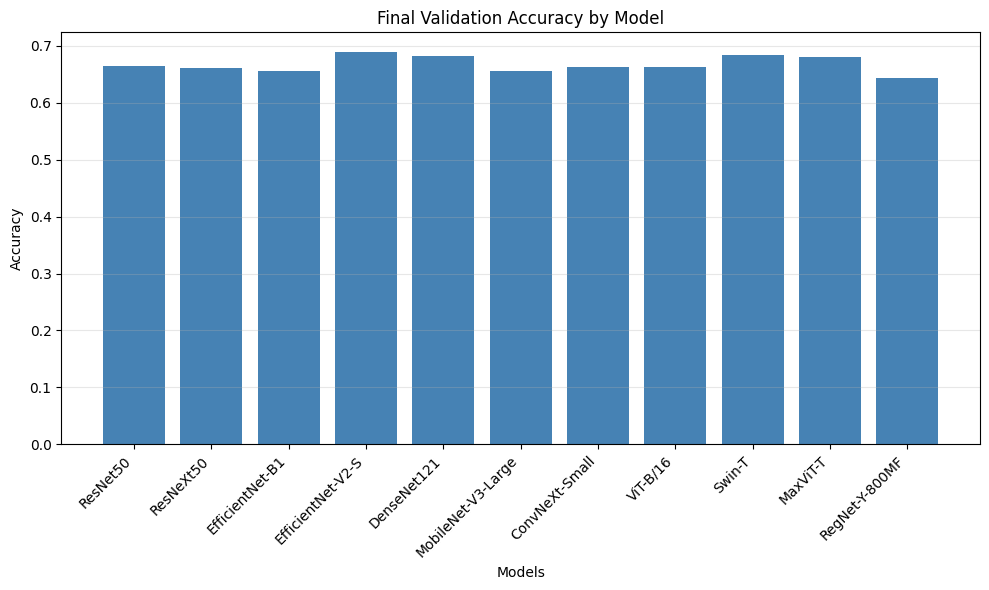

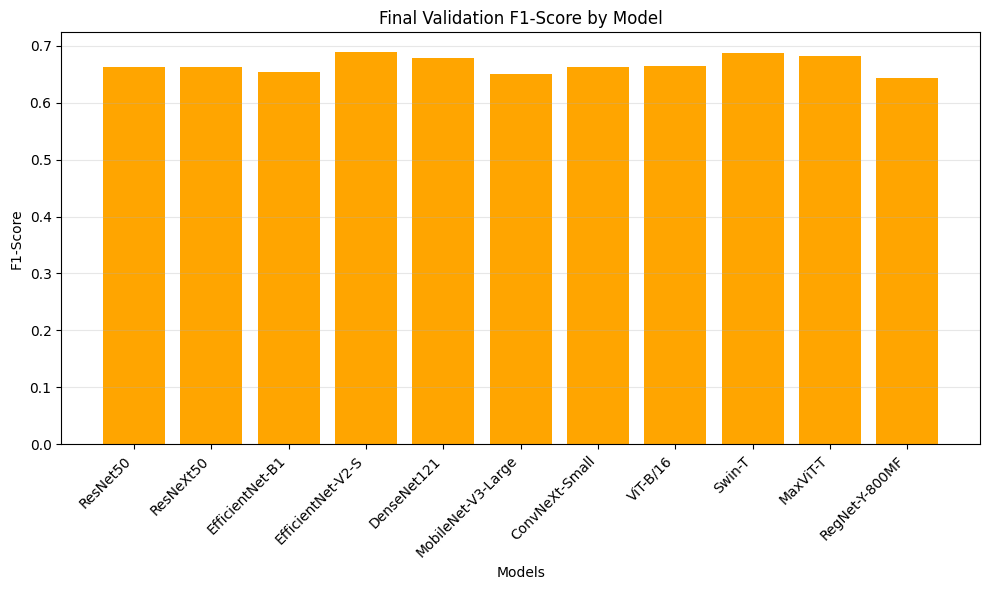

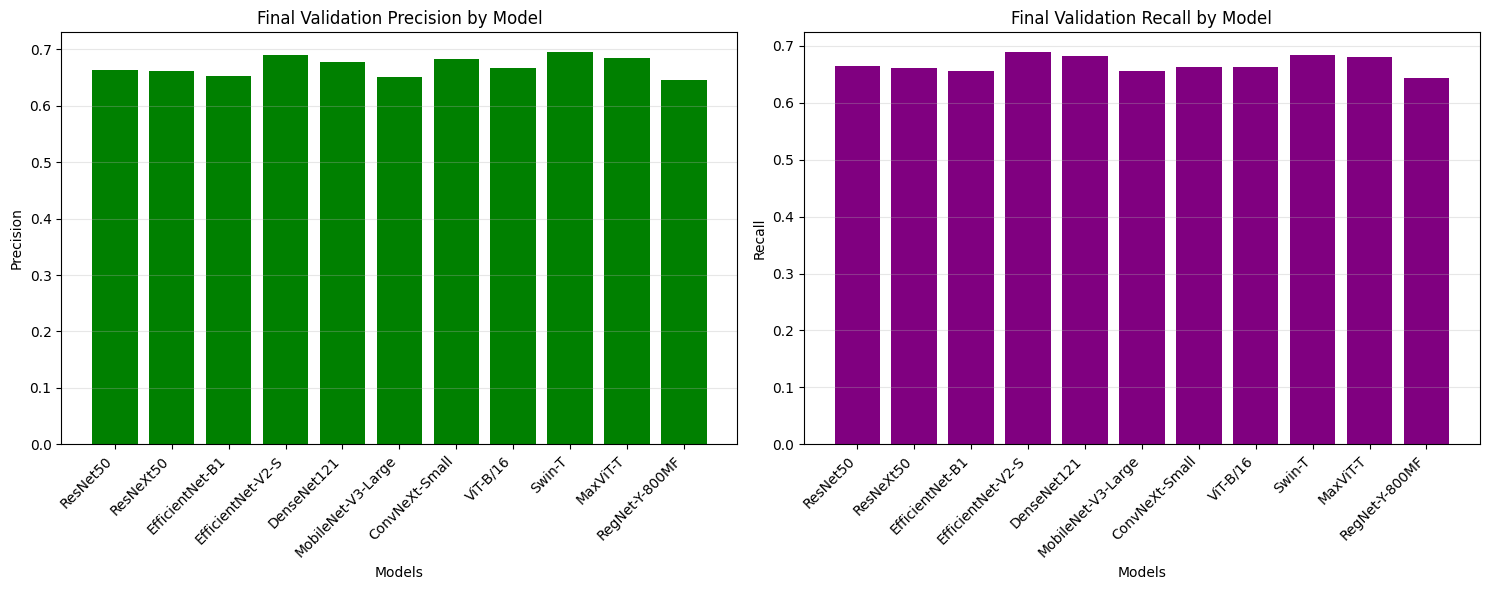

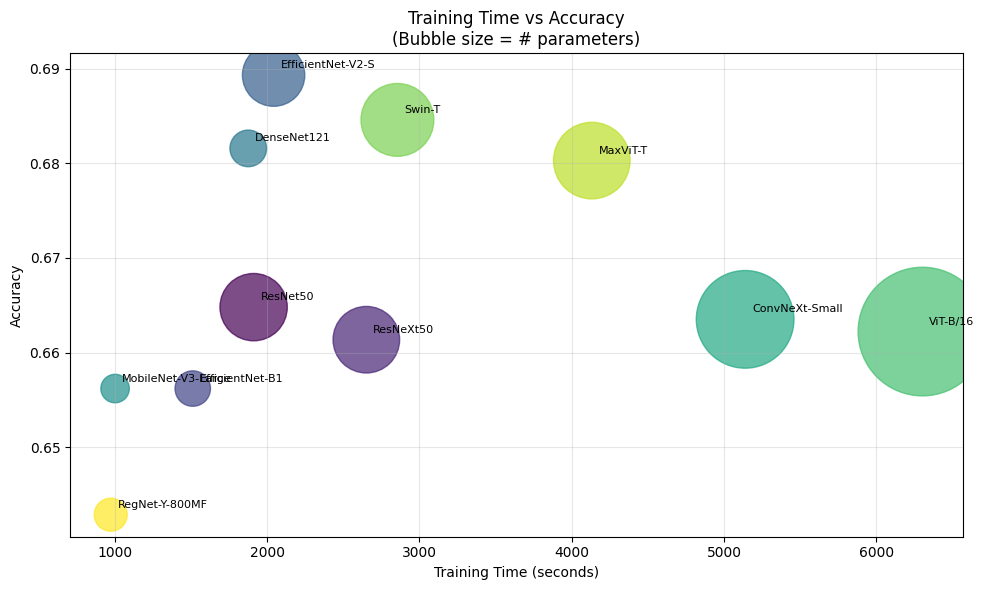

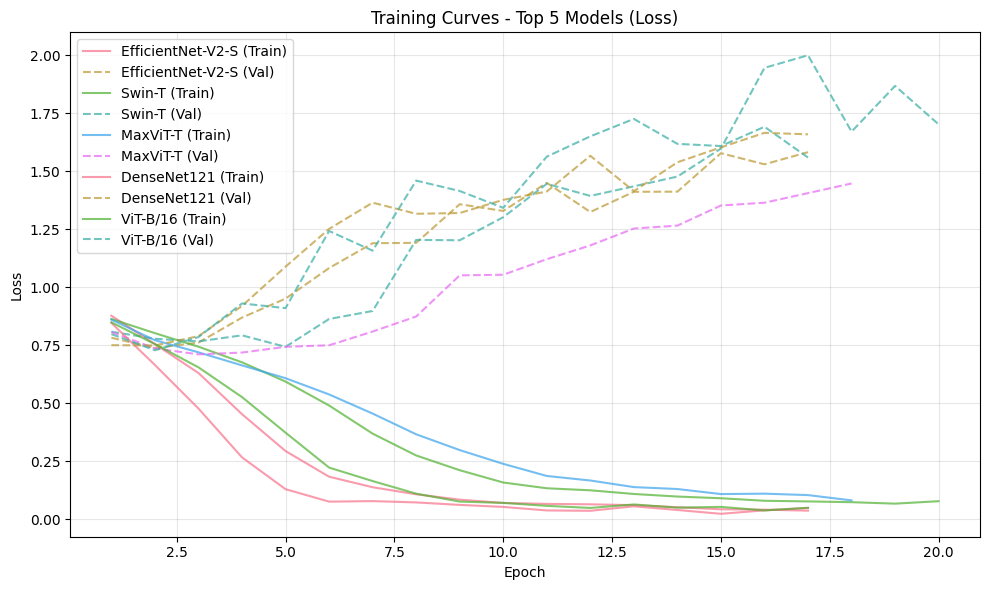

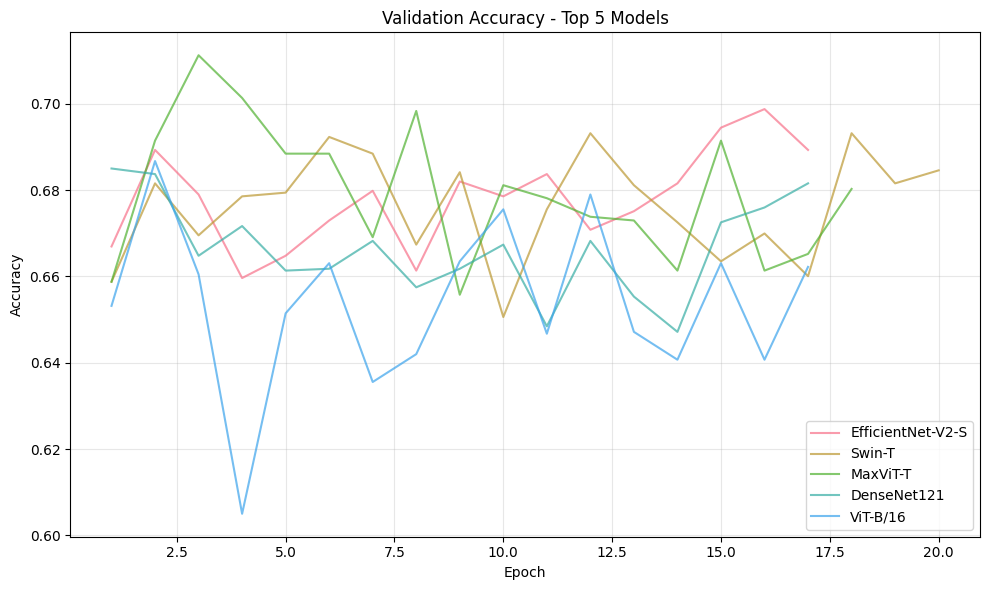

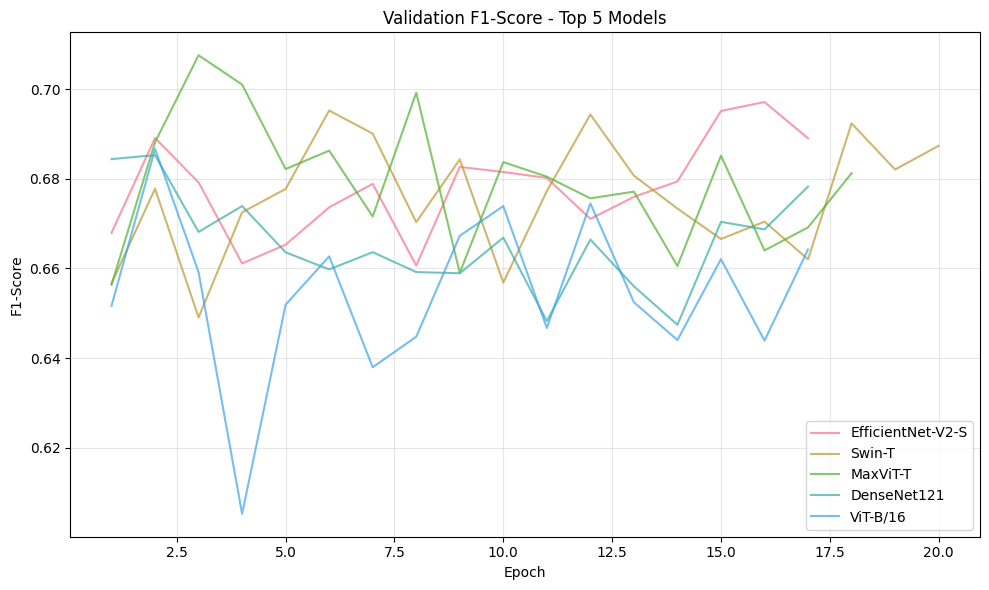

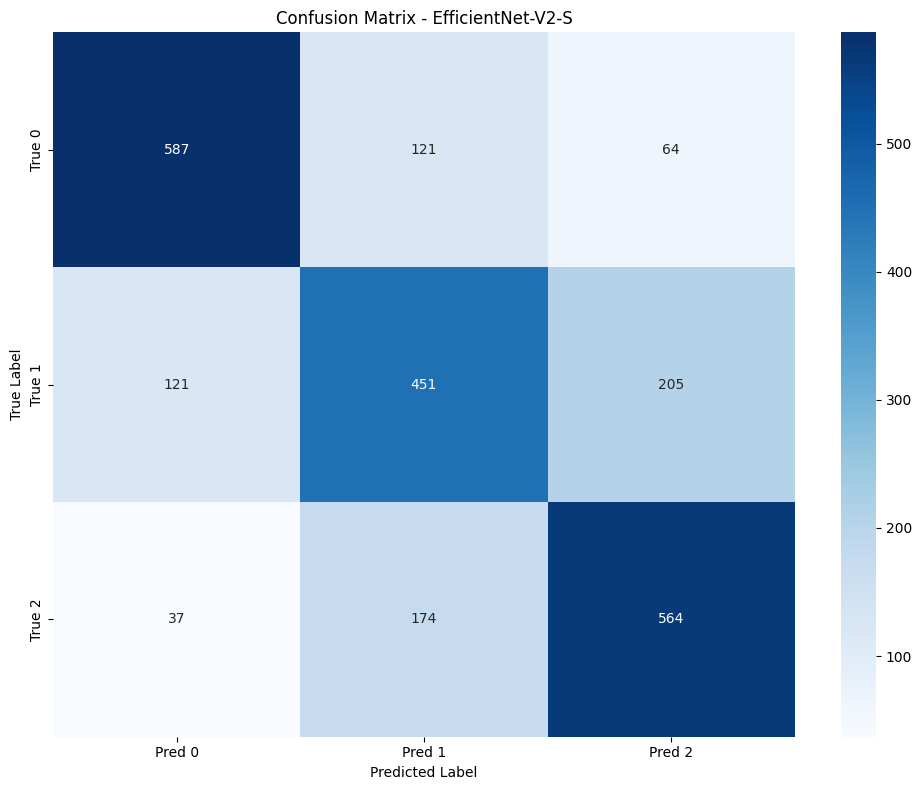


🔍 Generating GradCAM visualizations for top 1 model: EfficientNet-V2-S

--- Generating GradCAM visualizations for EfficientNet-V2-S ---
Using target layer: features
Image 1: True=1, Predicted=2, Confidence=98.00%
Image 2: True=0, Predicted=0, Confidence=99.96%
Image 3: True=2, Predicted=2, Confidence=97.86%
Image 4: True=1, Predicted=2, Confidence=98.21%
Image 5: True=2, Predicted=1, Confidence=99.33%


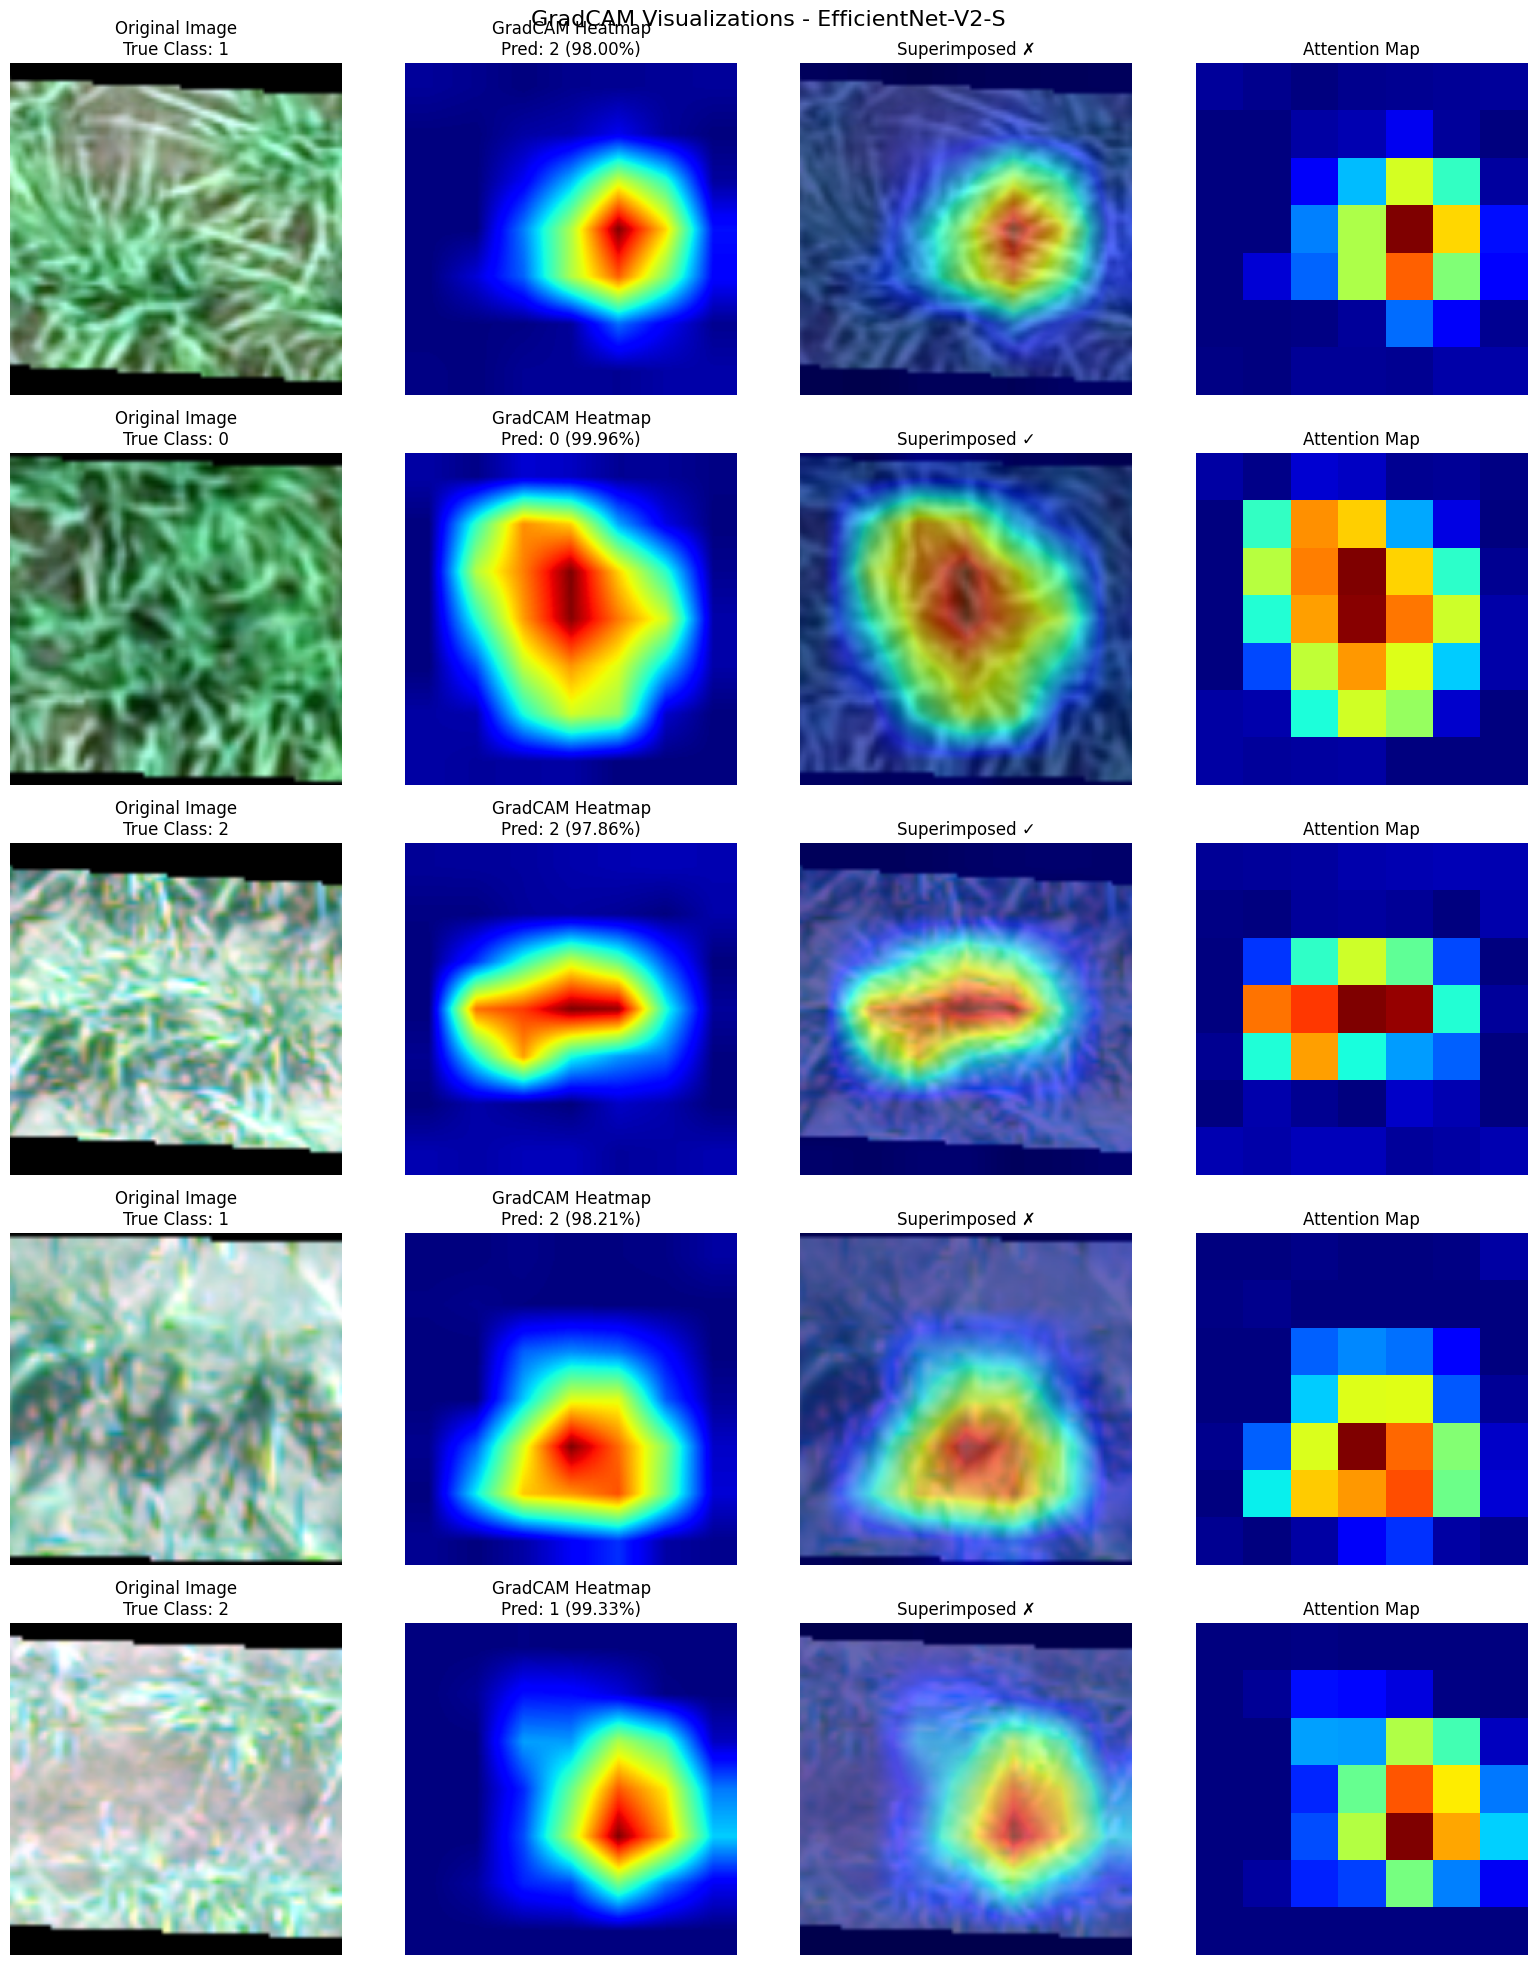


🔍 Generating GradCAM visualizations for top 2 model: Swin-T

--- Generating GradCAM visualizations for Swin-T ---
Using target layer: features.3
Image 1: True=1, Predicted=1, Confidence=99.98%
Image 2: True=2, Predicted=2, Confidence=100.00%
Image 3: True=2, Predicted=2, Confidence=100.00%
Image 4: True=2, Predicted=1, Confidence=99.06%
Image 5: True=2, Predicted=2, Confidence=100.00%


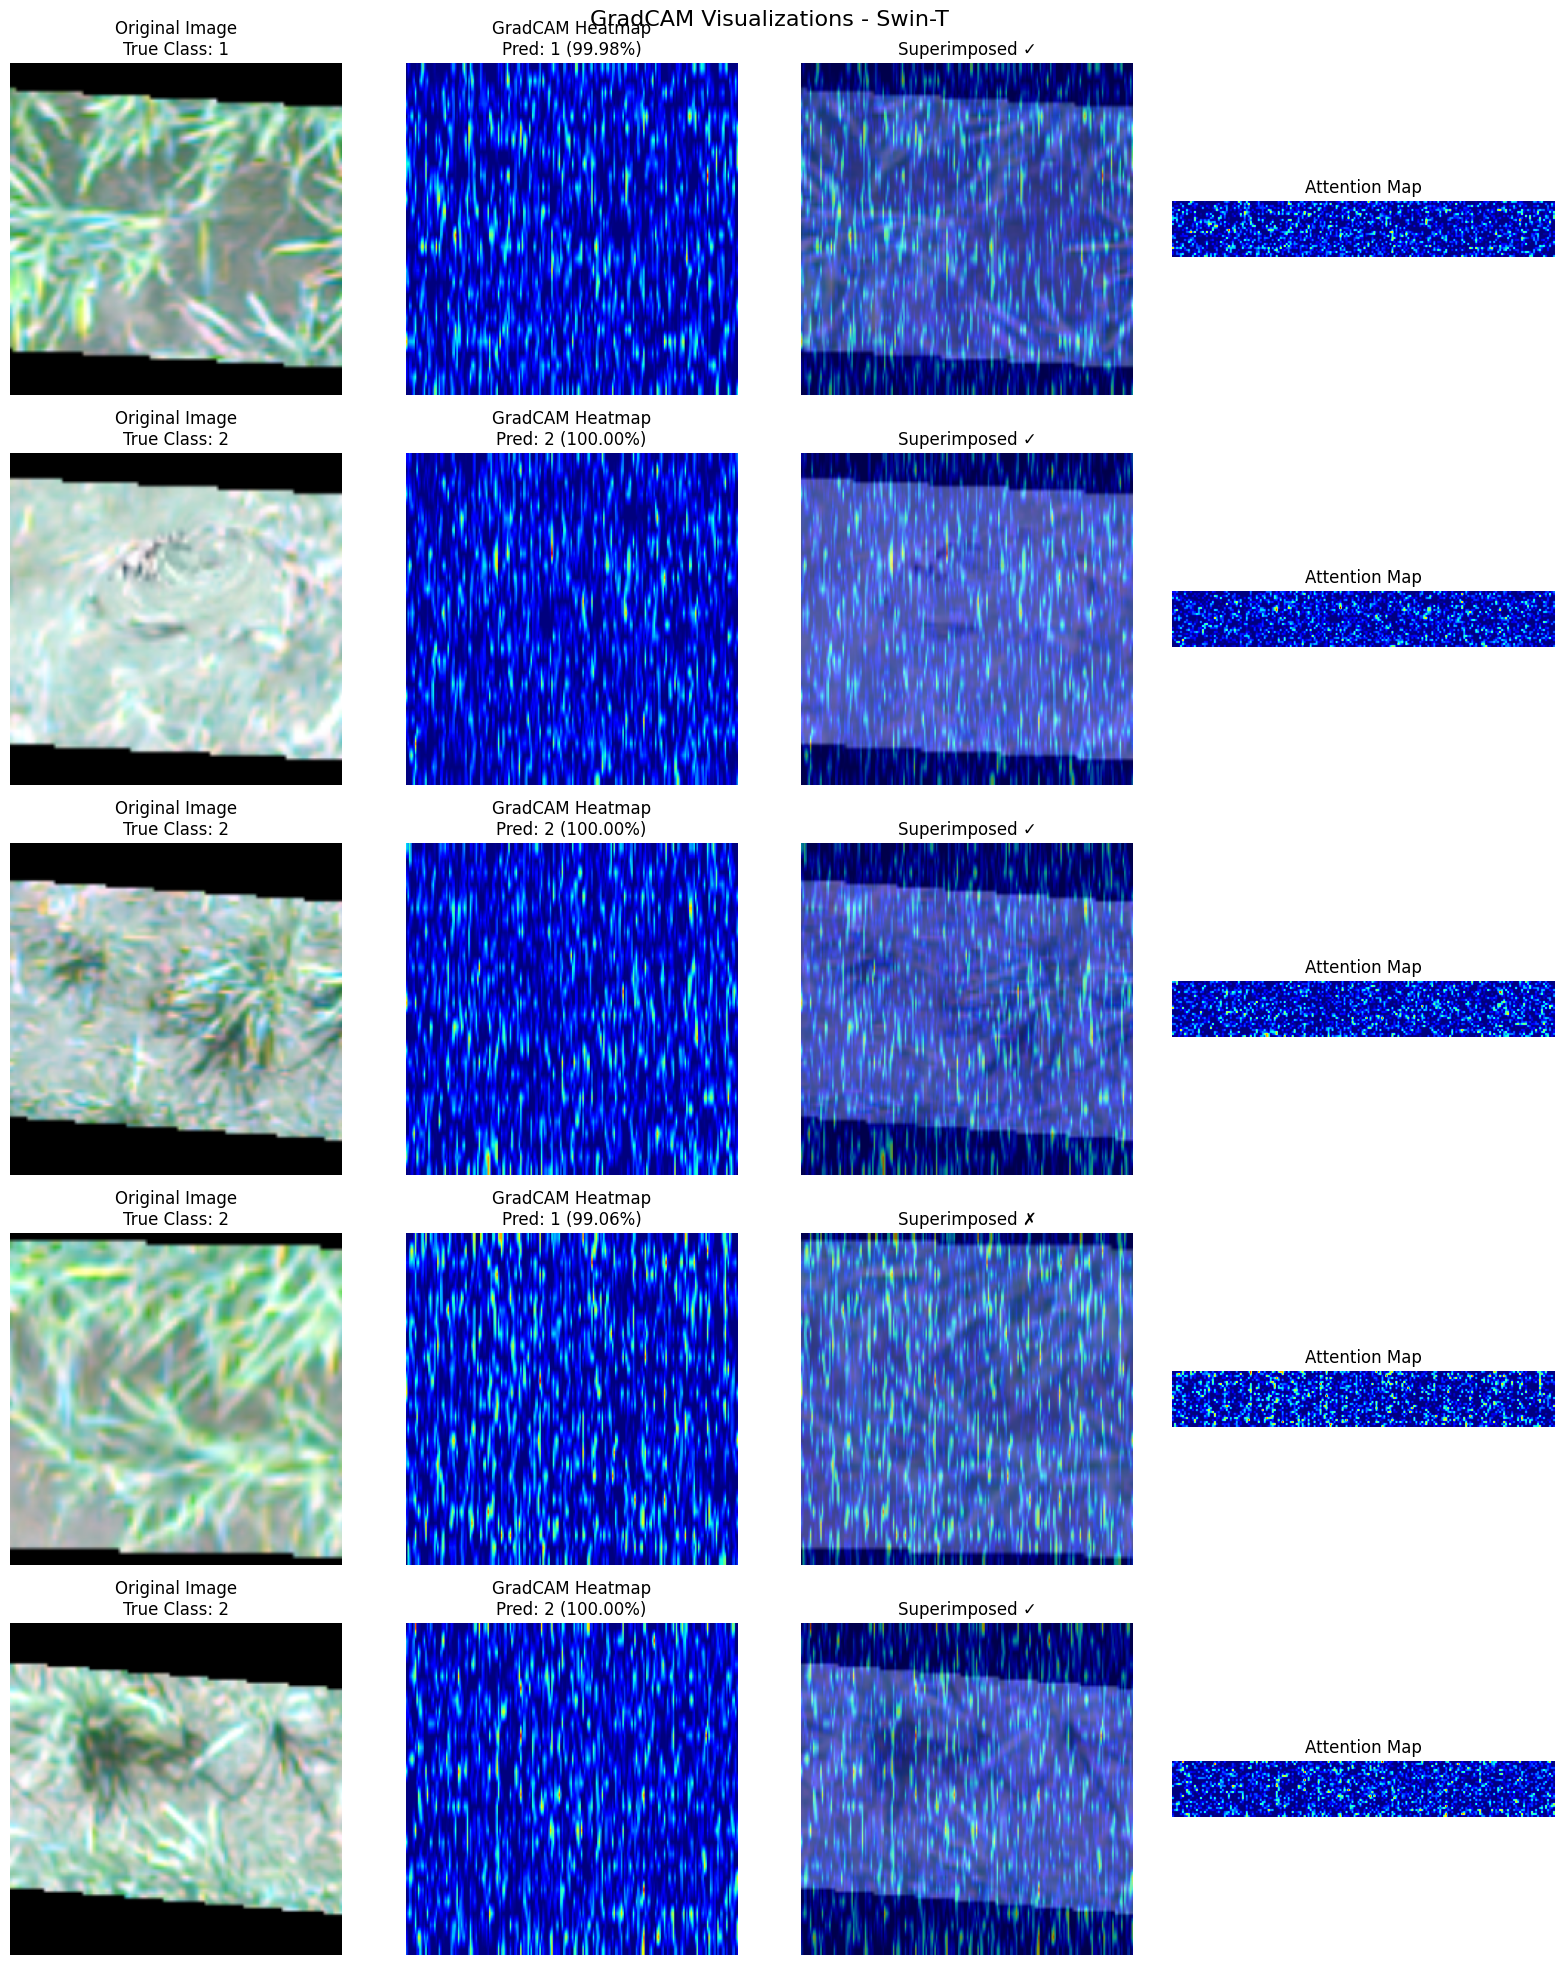


🔍 Generating GradCAM visualizations for top 3 model: MaxViT-T

--- Generating GradCAM visualizations for MaxViT-T ---
Using target layer: encoder.layers.11
Error processing image 0: 'NoneType' object is not subscriptable
Error processing image 1: 'NoneType' object is not subscriptable
Error processing image 2: 'NoneType' object is not subscriptable
Error processing image 3: 'NoneType' object is not subscriptable
Error processing image 4: 'NoneType' object is not subscriptable


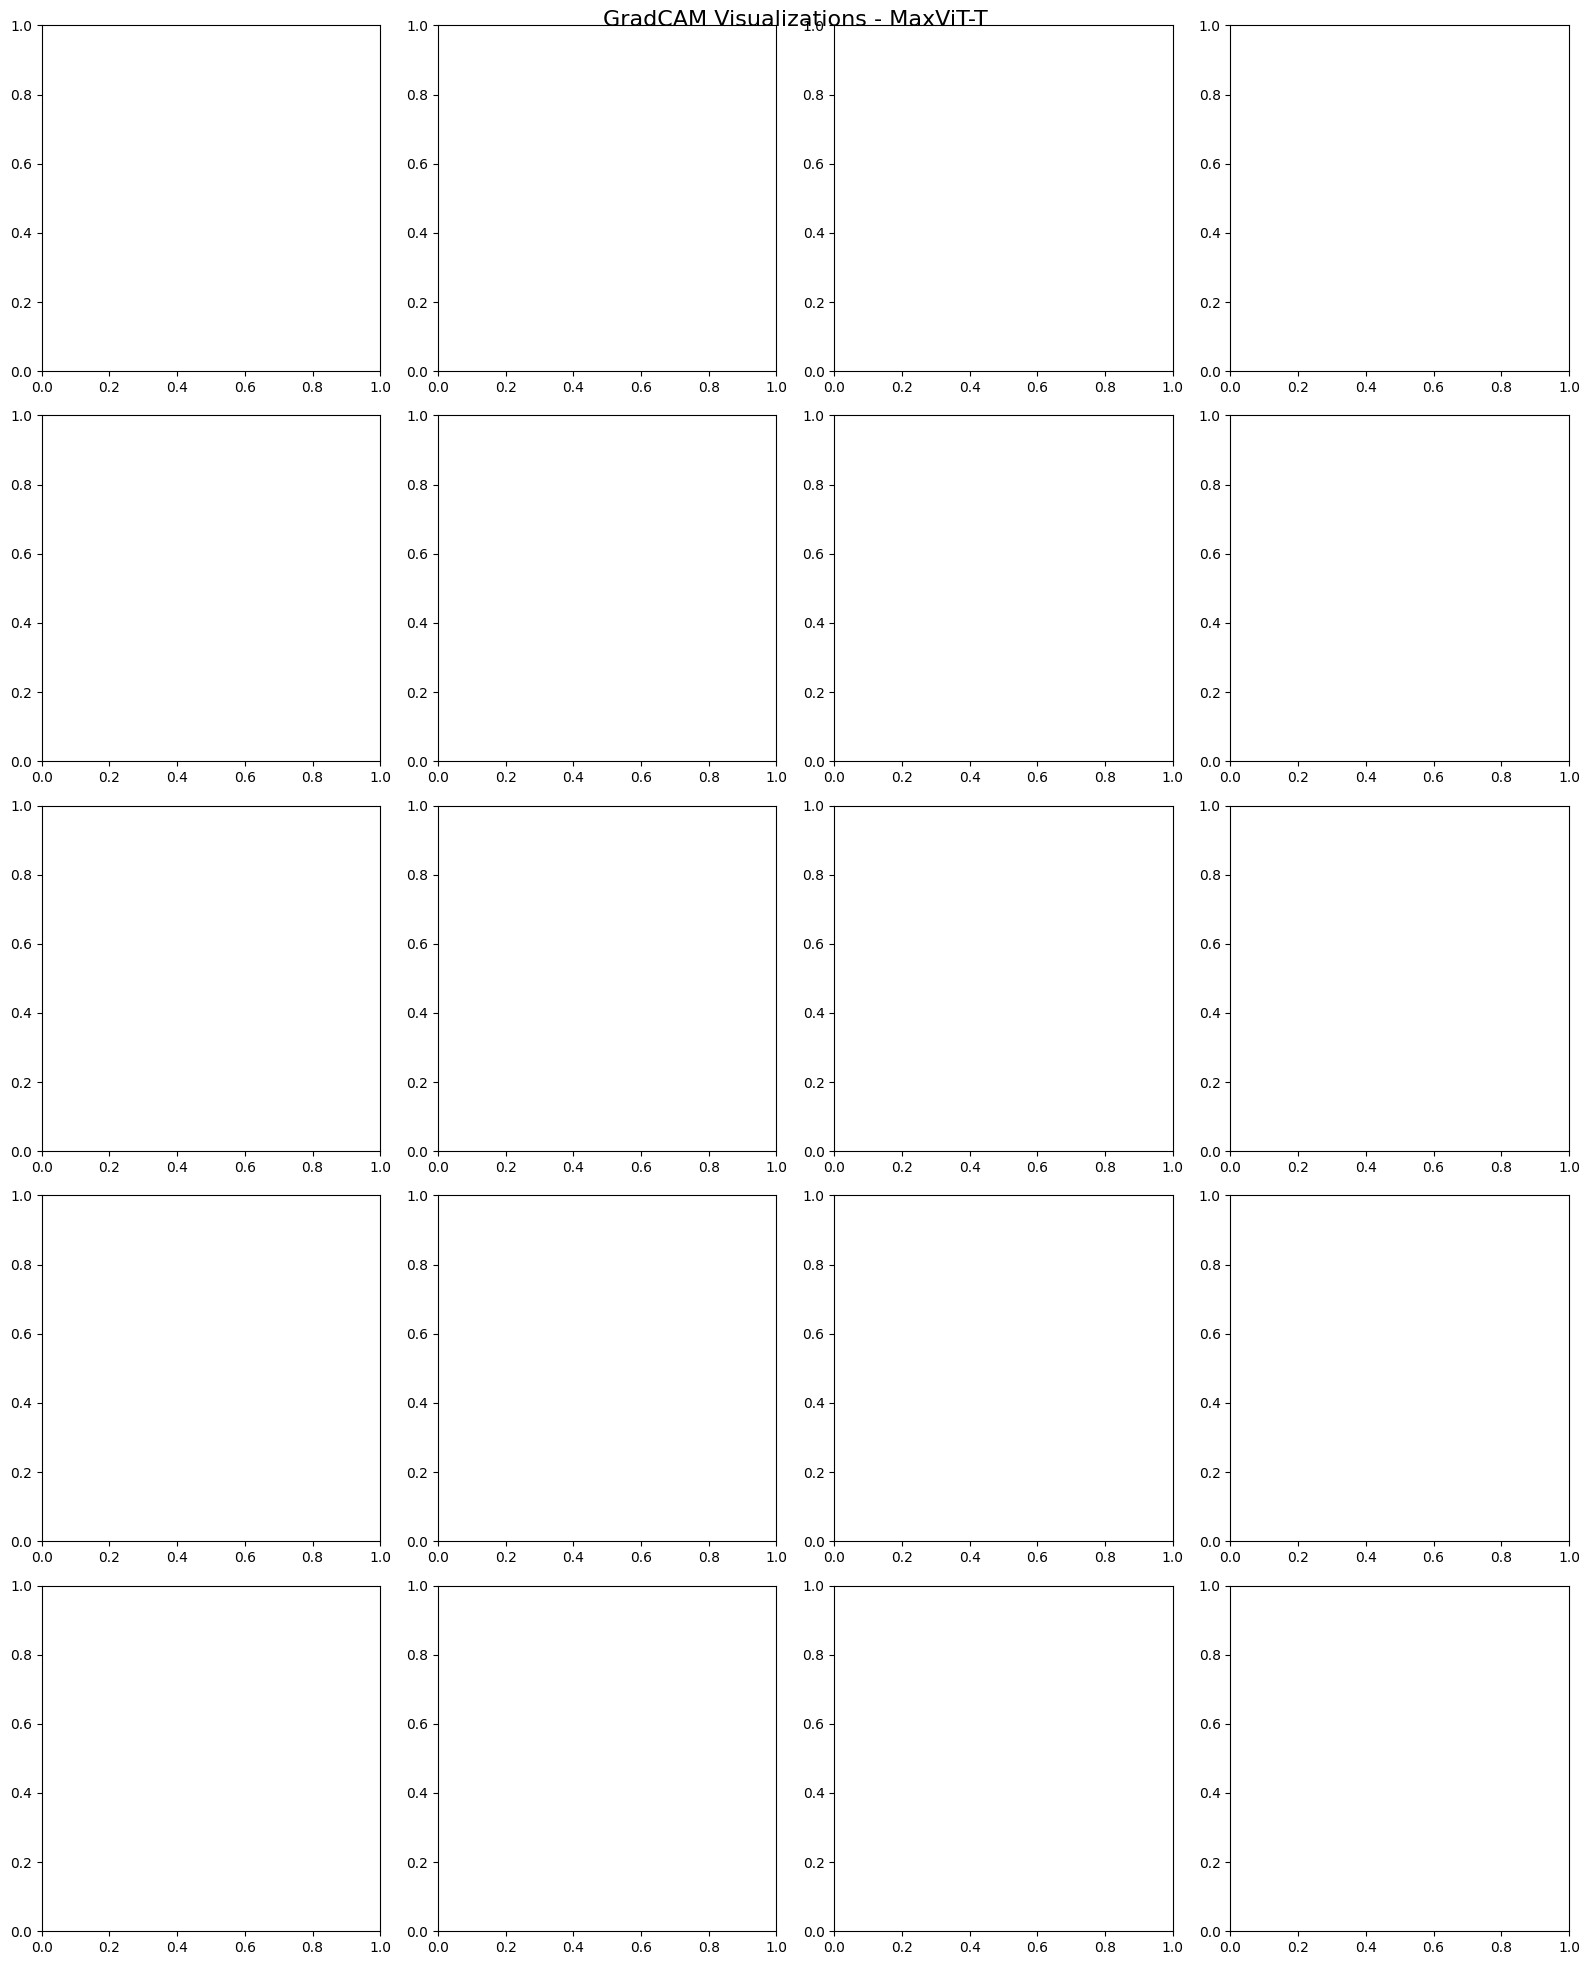


✅ Detailed results saved to 'model_comparison_results_classification.csv'
✅ GradCAM visualizations saved in 'gradcam_results/' directory


In [ ]:
import torch
import random
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as transforms
import torchvision.models as models
import pandas as pd
import numpy as np
from PIL import Image
import os
import glob
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, classification_report
import time
from collections import defaultdict
import warnings
import cv2
from torch.nn import functional as F
warnings.filterwarnings('ignore')

# --- Configuration ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Number of classes (Index values 1-8 mapped to 0-7)
NUM_CLASSES = 3

# --- GradCAM Implementation ---
class GradCAM:
    def __init__(self, model, target_layer_name):
        self.model = model
        self.target_layer_name = target_layer_name
        self.gradients = None
        self.activations = None
        self.hooks = []
        self._register_hooks()

    def _register_hooks(self):
        def backward_hook(module, grad_input, grad_output):
            self.gradients = grad_output[0]

        def forward_hook(module, input, output):
            self.activations = output

        for name, module in self.model.named_modules():
            if name == self.target_layer_name:
                self.hooks.append(module.register_forward_hook(forward_hook))
                self.hooks.append(module.register_backward_hook(backward_hook))
                break

    def generate_cam(self, input_tensor, class_idx=None):
        # Forward pass
        model_output = self.model(input_tensor)

        if class_idx is None:
            # Use predicted class
            class_idx = torch.argmax(model_output, dim=1).item()

        # Get score for target class
        score = model_output[:, class_idx]

        # Backward pass
        self.model.zero_grad()
        score.backward(retain_graph=True)

        # Generate CAM
        gradients = self.gradients[0].cpu().data.numpy()
        activations = self.activations[0].cpu().data.numpy()

        weights = np.mean(gradients, axis=(1, 2))
        cam = np.zeros(activations.shape[1:], dtype=np.float32)

        for i, w in enumerate(weights):
            cam += w * activations[i, :, :]

        cam = np.maximum(cam, 0)
        if cam.max() > 0:
            cam = cam / cam.max()

        return cam, class_idx, model_output

    def __del__(self):
        for hook in self.hooks:
            hook.remove()


def get_target_layer_name(model_name):
    """Get the appropriate target layer name for GradCAM"""
    if "resnet" in model_name.lower() or "resnext" in model_name.lower():
        return "layer4"
    elif "efficientnet" in model_name.lower():
        return "features"
    elif "densenet" in model_name.lower():
        return "features.denseblock4"
    elif "mobilenet" in model_name.lower():
        return "features"
    elif "convnext" in model_name.lower():
        return "features.7"
    elif "vit" in model_name.lower():
        return "encoder.layers.11"
    elif "swin" in model_name.lower():
        return "features.3"
    elif "maxvit" in model_name.lower():
        return "stem"
    elif "regnet" in model_name.lower():
        return "trunk_output"
    else:
        return "features"


def apply_colormap_on_image(org_im, activation, colormap_name='jet'):
    """Apply colormap on image"""
    activation = cv2.resize(activation, (org_im.shape[1], org_im.shape[0]))
    colormap = plt.cm.get_cmap(colormap_name)
    heatmap = colormap(activation)
    heatmap = np.uint8(255 * heatmap[:, :, :3])
    superimposed_img = heatmap * 0.6 + org_im * 0.4
    superimposed_img = np.clip(superimposed_img, 0, 255).astype(np.uint8)
    return superimposed_img, heatmap


def visualize_gradcam(model, model_name, dataset, device, num_images=5, save_path="gradcam_results"):
    """Generate GradCAM visualizations for classification"""
    print(f"\n--- Generating GradCAM visualizations for {model_name} ---")
    os.makedirs(save_path, exist_ok=True)

    target_layer = get_target_layer_name(model_name)
    print(f"Using target layer: {target_layer}")

    try:
        grad_cam = GradCAM(model, target_layer)
    except Exception as e:
        print(f"Could not initialize GradCAM for {model_name}: {e}")
        return

    model.eval()
    indices = np.random.choice(len(dataset), min(num_images, len(dataset)), replace=False)

    fig, axes = plt.subplots(num_images, 4, figsize=(16, 4*num_images))
    if num_images == 1:
        axes = axes.reshape(1, -1)

    for idx, img_idx in enumerate(indices):
        try:
            image, target = dataset[img_idx]
            img_np = image.permute(1, 2, 0).cpu().numpy()

            # Denormalize
            mean = np.array([0.485, 0.456, 0.406])
            std = np.array([0.229, 0.224, 0.225])
            img_np = (img_np * std + mean)
            img_np = np.clip(img_np, 0, 1)
            img_np = (img_np * 255).astype(np.uint8)

            input_tensor = image.unsqueeze(0).to(device)

            # Generate GradCAM for predicted class
            cam, predicted_class, model_output = grad_cam.generate_cam(input_tensor)

            # Get probabilities
            probs = F.softmax(model_output, dim=1)
            confidence = probs[0, predicted_class].item()

            superimposed_img, heatmap = apply_colormap_on_image(img_np, cam)

            # Original image
            axes[idx, 0].imshow(img_np)
            axes[idx, 0].set_title(f'Original Image\nTrue Class: {int(target)}')
            axes[idx, 0].axis('off')

            # Heatmap
            axes[idx, 1].imshow(heatmap)
            axes[idx, 1].set_title(f'GradCAM Heatmap\nPred: {predicted_class} ({confidence:.2%})')
            axes[idx, 1].axis('off')

            # Superimposed
            correct = "✓" if predicted_class == int(target) else "✗"
            axes[idx, 2].imshow(superimposed_img)
            axes[idx, 2].set_title(f'Superimposed {correct}')
            axes[idx, 2].axis('off')

            # CAM only
            axes[idx, 3].imshow(cam, cmap='jet')
            axes[idx, 3].set_title('Attention Map')
            axes[idx, 3].axis('off')

            print(f"Image {idx+1}: True={int(target)}, Predicted={predicted_class}, Confidence={confidence:.2%}")

        except Exception as e:
            print(f"Error processing image {idx}: {e}")
            continue

    plt.suptitle(f'GradCAM Visualizations - {model_name}', fontsize=16, y=0.98)
    plt.tight_layout()
    plt.savefig(f'{save_path}/gradcam_{model_name.replace("/", "_").replace(" ", "_")}.png',
                dpi=300, bbox_inches='tight')
    plt.show()

    del grad_cam
    torch.cuda.empty_cache()


class EarlyStopping:
    def __init__(self, patience=7, min_delta=0, restore_best_weights=True):
        self.patience = patience
        self.min_delta = min_delta
        self.restore_best_weights = restore_best_weights
        self.best_loss = None
        self.counter = 0
        self.best_weights = None

    def __call__(self, val_loss, model):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.save_checkpoint(model)
        elif val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            self.save_checkpoint(model)
        else:
            self.counter += 1

        if self.counter >= self.patience:
            if self.restore_best_weights:
                model.load_state_dict(self.best_weights)
            return True
        return False

    def save_checkpoint(self, model):
        self.best_weights = model.state_dict().copy()


# --- Custom Dataset Class for Classification ---
import os
import glob
import torch
import pandas as pd
import numpy as np
from torch.utils.data import Dataset
from PIL import Image

NUM_CLASSES = 3  # Original number of classes (0–7)
BIN_MAPPING = {
    0: 0,        # bin1
    1: 0, 2: 0,  # bin2
    3: 0, 4: 1, 5: 1, 6: 2, 7: 2, 8: 2  # bin3
}

class ImageClassificationDataset(Dataset):
    def __init__(self, image_folder, csv_file, transform=None, target_col="Index"):
        assert len(image_folder) == len(csv_file), "image_folders and csv_files must have the same length"

        self.transform = transform

        # Temporary storage for all samples before balancing
        temp_image_paths = []
        temp_targets = []

        for img_folder, csv_path in zip(image_folder, csv_file):
            df = pd.read_csv(csv_path)
            df['PLOT'] = pd.to_numeric(df['PLOT'], errors='coerce')
            df = df.replace([float('inf'), float('-inf')], pd.NA)
            df = df.dropna(subset=['PLOT'])

            df[target_col] = pd.to_numeric(df[target_col], errors='coerce')
            df = df.replace([float('inf'), float('-inf')], pd.NA)
            df = df.dropna(subset=[target_col])

            df['PLOT'] = df['PLOT'].astype(int)
            df[target_col] = df[target_col].astype(float)

            # Convert Index values (1.0–8.0) to original class labels (0–7)
            df['class_label'] = (df[target_col] - 1).astype(int)

            # Filter out invalid classes
            valid_mask = (df['class_label'] >= 0) & (df['class_label'] < 9)
            df = df[valid_mask]

            # Apply binning
            df['binned_label'] = df['class_label'].map(BIN_MAPPING)

            id_to_target = dict(zip(df['PLOT'], df['binned_label']))
            image_files = glob.glob(os.path.join(img_folder, "*.png"))

            for img_path in image_files:
                filename = os.path.basename(img_path)
                try:
                    plot_id = int(filename.split('_')[-1].split('.')[0])
                except Exception as e:
                    raise ValueError(f"Filename format error for {filename}: {e}")

                if plot_id in id_to_target:
                    temp_image_paths.append(img_path)
                    temp_targets.append(id_to_target[plot_id])

            print(f"✅ Loaded {len(image_files)} images from {img_folder}")

        print(f"✅ Total images loaded before balancing: {len(temp_image_paths)}")

        # Print original class distribution
        unique, counts = np.unique(temp_targets, return_counts=True)
        print(f"\n📊 Original Binned Class Distribution:")
        for cls, cnt in zip(unique, counts):
            print(f"   Bin {cls}: {cnt} samples ({cnt/len(temp_targets)*100:.1f}%)")

        # Balance the dataset by selecting first n samples from each class
        # where n = min(samples per class)
        min_samples = min(counts)
        print(f"\n⚖️ Balancing to {min_samples} samples per class...")

        # Group samples by class
        class_samples = {cls: [] for cls in unique}
        for img_path, target in zip(temp_image_paths, temp_targets):
            class_samples[target].append((img_path, target))

        # Select random n samples from each class
        self.image_paths = []
        self.targets = []

        for cls in sorted(class_samples.keys()):
            selected_samples = random.sample(class_samples[cls], min_samples)
            for img_path, target in selected_samples:
                self.image_paths.append(img_path)
                self.targets.append(target)

        # Print balanced class distribution
        unique, counts = np.unique(self.targets, return_counts=True)
        print(f"\n📊 Balanced Class Distribution:")
        for cls, cnt in zip(unique, counts):
            print(f"   Bin {cls}: {cnt} samples ({cnt/len(self.targets)*100:.1f}%)")

        print(f"✅ Final dataset size after balancing: {len(self.image_paths)} samples")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        target = self.targets[idx]

        try:
            image = Image.open(img_path).convert("RGB")
        except Exception as e:
            print(f"Error opening image {img_path}: {e}. Skipping.")
            return None

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(target, dtype=torch.long)


# --- Model Building Function for Classification ---
def get_classification_model(model_name, num_classes=NUM_CLASSES, fine_tune_mode="full"):
    """Get a pretrained model for classification"""
    model = None

    # ResNet Family
    if model_name == "resnet18":
        model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        num_ftrs = model.fc.in_features
        model.fc = nn.Linear(num_ftrs, num_classes)
    elif model_name == "resnet34":
        model = models.resnet34(weights=models.ResNet34_Weights.DEFAULT)
        num_ftrs = model.fc.in_features
        model.fc = nn.Linear(num_ftrs, num_classes)
    elif model_name == "resnet50":
        model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        num_ftrs = model.fc.in_features
        model.fc = nn.Linear(num_ftrs, num_classes)
    elif model_name == "resnet101":
        model = models.resnet101(weights=models.ResNet101_Weights.DEFAULT)
        num_ftrs = model.fc.in_features
        model.fc = nn.Linear(num_ftrs, num_classes)
    elif model_name == "resnext50":
        model = models.resnext50_32x4d(weights=models.ResNeXt50_32X4D_Weights.DEFAULT)
        num_ftrs = model.fc.in_features
        model.fc = nn.Linear(num_ftrs, num_classes)
    elif model_name == "resnext101":
        model = models.resnext101_32x8d(weights=models.ResNeXt101_32X8D_Weights.DEFAULT)
        num_ftrs = model.fc.in_features
        model.fc = nn.Linear(num_ftrs, num_classes)

    # EfficientNet Family
    elif model_name == "efficientnet_b0":
        model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
    elif model_name == "efficientnet_b1":
        model = models.efficientnet_b1(weights=models.EfficientNet_B1_Weights.DEFAULT)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
    elif model_name == "efficientnet_b2":
        model = models.efficientnet_b2(weights=models.EfficientNet_B2_Weights.DEFAULT)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
    elif model_name == "efficientnet_v2_s":
        model = models.efficientnet_v2_s(weights=models.EfficientNet_V2_S_Weights.DEFAULT)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
    elif model_name == "efficientnet_v2_m":
        model = models.efficientnet_v2_m(weights=models.EfficientNet_V2_M_Weights.DEFAULT)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)

    # DenseNet Family
    elif model_name == "densenet121":
        model = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)
        model.classifier = nn.Linear(model.classifier.in_features, num_classes)
    elif model_name == "densenet161":
        model = models.densenet161(weights=models.DenseNet161_Weights.DEFAULT)
        model.classifier = nn.Linear(model.classifier.in_features, num_classes)
    elif model_name == "densenet169":
        model = models.densenet169(weights=models.DenseNet169_Weights.DEFAULT)
        model.classifier = nn.Linear(model.classifier.in_features, num_classes)

    # MobileNet Family
    elif model_name == "mobilenet_v2":
        model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
    elif model_name == "mobilenet_v3_small":
        model = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.DEFAULT)
        model.classifier[3] = nn.Linear(model.classifier[3].in_features, num_classes)
    elif model_name == "mobilenet_v3_large":
        model = models.mobilenet_v3_large(weights=models.MobileNet_V3_Large_Weights.DEFAULT)
        model.classifier[3] = nn.Linear(model.classifier[3].in_features, num_classes)

    # ConvNeXt Family
    elif model_name == "convnext_tiny":
        model = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.DEFAULT)
        model.classifier[2] = nn.Linear(model.classifier[2].in_features, num_classes)
    elif model_name == "convnext_small":
        model = models.convnext_small(weights=models.ConvNeXt_Small_Weights.DEFAULT)
        model.classifier[2] = nn.Linear(model.classifier[2].in_features, num_classes)
    elif model_name == "convnext_base":
        model = models.convnext_base(weights=models.ConvNeXt_Base_Weights.DEFAULT)
        model.classifier[2] = nn.Linear(model.classifier[2].in_features, num_classes)

    # Vision Transformers
    elif model_name == "vit_b_16":
        model = models.vit_b_16(weights=models.ViT_B_16_Weights.DEFAULT)
        model.heads.head = nn.Linear(model.heads.head.in_features, num_classes)
    elif model_name == "vit_b_32":
        model = models.vit_b_32(weights=models.ViT_B_32_Weights.DEFAULT)
        model.heads.head = nn.Linear(model.heads.head.in_features, num_classes)
    elif model_name == "vit_l_16":
        model = models.vit_l_16(weights=models.ViT_L_16_Weights.DEFAULT)
        model.heads.head = nn.Linear(model.heads.head.in_features, num_classes)
    elif model_name == "swin_t":
        model = models.swin_t(weights=models.Swin_T_Weights.DEFAULT)
        model.head = nn.Linear(model.head.in_features, num_classes)
    elif model_name == "swin_s":
        model = models.swin_s(weights=models.Swin_S_Weights.DEFAULT)
        model.head = nn.Linear(model.head.in_features, num_classes)
    elif model_name == "swin_b":
        model = models.swin_b(weights=models.Swin_B_Weights.DEFAULT)
        model.head = nn.Linear(model.head.in_features, num_classes)
    elif model_name == "maxvit_t":
        model = models.maxvit_t(weights=models.MaxVit_T_Weights.DEFAULT)
        model.classifier[5] = nn.Linear(model.classifier[5].in_features, num_classes)

    # RegNet Family
    elif model_name == "regnet_y_400mf":
        model = models.regnet_y_400mf(weights=models.RegNet_Y_400MF_Weights.DEFAULT)
        model.fc = nn.Linear(model.fc.in_features, num_classes)
    elif model_name == "regnet_y_800mf":
        model = models.regnet_y_800mf(weights=models.RegNet_Y_800MF_Weights.DEFAULT)
        model.fc = nn.Linear(model.fc.in_features, num_classes)
    elif model_name == "regnet_y_1_6gf":
        model = models.regnet_y_1_6gf(weights=models.RegNet_Y_1_6GF_Weights.DEFAULT)
        model.fc = nn.Linear(model.fc.in_features, num_classes)

    else:
        raise ValueError(f"Invalid model name: {model_name}")

    # Apply fine-tuning strategy
    if fine_tune_mode == "freeze":
        for param in model.parameters():
            param.requires_grad = False
        if hasattr(model, 'fc'):
            for param in model.fc.parameters():
                param.requires_grad = True
        elif hasattr(model, 'classifier'):
            for param in model.classifier.parameters():
                param.requires_grad = True
        elif hasattr(model, 'head'):
            for param in model.head.parameters():
                param.requires_grad = True
        elif hasattr(model, 'heads'):
            for param in model.heads.parameters():
                param.requires_grad = True
    elif fine_tune_mode == "partial":
        total_layers = len(list(model.parameters()))
        layers_to_freeze = total_layers // 2
        for i, param in enumerate(model.parameters()):
            param.requires_grad = i >= layers_to_freeze

    return model


def count_parameters(model):
    """Count trainable parameters in the model"""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def train_and_evaluate_model(model_name, model, train_loader, val_loader, device,
                           max_epochs=100, patience=10, lr=0.001):
    """Train and evaluate a classification model"""
    print(f"\n--- Training {model_name} ---")
    print(f"Trainable parameters: {count_parameters(model):,}")

    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam([p for p in model.parameters() if p.requires_grad], lr=lr)
    early_stopping = EarlyStopping(patience=patience, min_delta=0.001)

    # Track metrics
    train_losses = []
    val_losses = []
    val_accuracies = []
    val_f1_scores = []
    val_precisions = []
    val_recalls = []

    start_time = time.time()

    for epoch in range(max_epochs):
        # Training phase
        model.train()
        running_loss = 0.0
        for images, targets in train_loader:
            if images is None or targets is None:
                continue

            images, targets = images.to(device), targets.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        avg_train_loss = running_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # Validation phase
        model.eval()
        val_loss = 0.0
        all_preds = []
        all_targets = []

        with torch.no_grad():
            for images, targets in val_loader:
                if images is None or targets is None:
                    continue

                images, targets = images.to(device), targets.to(device)
                outputs = model(images)
                loss = criterion(outputs, targets)
                val_loss += loss.item()

                _, predicted = torch.max(outputs, 1)
                all_preds.extend(predicted.cpu().numpy())
                all_targets.extend(targets.cpu().numpy())

        avg_val_loss = val_loss / len(val_loader)
        val_accuracy = accuracy_score(all_targets, all_preds)
        val_f1 = f1_score(all_targets, all_preds, average='weighted', zero_division=0)
        val_precision = precision_score(all_targets, all_preds, average='weighted', zero_division=0)
        val_recall = recall_score(all_targets, all_preds, average='weighted', zero_division=0)

        val_losses.append(avg_val_loss)
        val_accuracies.append(val_accuracy)
        val_f1_scores.append(val_f1)
        val_precisions.append(val_precision)
        val_recalls.append(val_recall)

        if epoch % 10 == 0:
            print(f"Epoch [{epoch+1}/{max_epochs}], Train Loss: {avg_train_loss:.4f}, "
                  f"Val Loss: {avg_val_loss:.4f}, Acc: {val_accuracy:.4f}, "
                  f"F1: {val_f1:.4f}, Prec: {val_precision:.4f}, Rec: {val_recall:.4f}")

        if early_stopping(avg_val_loss, model):
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

    training_time = time.time() - start_time

    # Final evaluation
    model.eval()
    final_preds = []
    final_targets = []

    with torch.no_grad():
        for images, targets in val_loader:
            if images is None or targets is None:
                continue

            images, targets = images.to(device), targets.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            final_preds.extend(predicted.cpu().numpy())
            final_targets.extend(targets.cpu().numpy())

    final_accuracy = accuracy_score(final_targets, final_preds)
    final_f1 = f1_score(final_targets, final_preds, average='weighted', zero_division=0)
    final_precision = precision_score(final_targets, final_preds, average='weighted', zero_division=0)
    final_recall = recall_score(final_targets, final_preds, average='weighted', zero_division=0)
    conf_matrix = confusion_matrix(final_targets, final_preds)

    return {
        'model': model,
        'final_accuracy': final_accuracy,
        'final_f1': final_f1,
        'final_precision': final_precision,
        'final_recall': final_recall,
        'confusion_matrix': conf_matrix,
        'training_time': training_time,
        'train_losses': train_losses,
        'val_losses': val_losses,
        'val_accuracies': val_accuracies,
        'val_f1_scores': val_f1_scores,
        'val_precisions': val_precisions,
        'val_recalls': val_recalls,
        'trainable_params': count_parameters(model),
        'epochs_trained': len(train_losses),
        'classification_report': classification_report(final_targets, final_preds,
                                                       target_names=[f"Class {i}" for i in range(NUM_CLASSES)],
                                                       zero_division=0)
    }


def plot_results(results):
    """Create comprehensive plots of the classification results"""
    plt.style.use('default')
    sns.set_palette("husl")

    model_names = list(results.keys())
    accuracy_values = [results[name]['final_accuracy'] for name in model_names]
    f1_values = [results[name]['final_f1'] for name in model_names]
    precision_values = [results[name]['final_precision'] for name in model_names]
    recall_values = [results[name]['final_recall'] for name in model_names]
    training_times = [results[name]['training_time'] for name in model_names]
    param_counts = [results[name]['trainable_params'] for name in model_names]

    # Accuracy Comparison
    plt.figure(figsize=(10, 6))
    plt.bar(range(len(model_names)), accuracy_values, color='steelblue')
    plt.title('Final Validation Accuracy by Model')
    plt.xlabel('Models')
    plt.ylabel('Accuracy')
    plt.xticks(range(len(model_names)), model_names, rotation=45, ha='right')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig('accuracy_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

    # F1 Score Comparison
    plt.figure(figsize=(10, 6))
    plt.bar(range(len(model_names)), f1_values, color='orange')
    plt.title('Final Validation F1-Score by Model')
    plt.xlabel('Models')
    plt.ylabel('F1-Score')
    plt.xticks(range(len(model_names)), model_names, rotation=45, ha='right')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig('f1_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Precision & Recall Comparison
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    ax1.bar(range(len(model_names)), precision_values, color='green')
    ax1.set_title('Final Validation Precision by Model')
    ax1.set_xlabel('Models')
    ax1.set_ylabel('Precision')
    ax1.set_xticks(range(len(model_names)))
    ax1.set_xticklabels(model_names, rotation=45, ha='right')
    ax1.grid(axis='y', alpha=0.3)

    ax2.bar(range(len(model_names)), recall_values, color='purple')
    ax2.set_title('Final Validation Recall by Model')
    ax2.set_xlabel('Models')
    ax2.set_ylabel('Recall')
    ax2.set_xticks(range(len(model_names)))
    ax2.set_xticklabels(model_names, rotation=45, ha='right')
    ax2.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig('precision_recall_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Training Time vs Accuracy
    plt.figure(figsize=(10, 6))
    scatter = plt.scatter(training_times, accuracy_values,
                         s=[p/10000 for p in param_counts],
                         alpha=0.7, c=range(len(model_names)), cmap='viridis')
    plt.title('Training Time vs Accuracy\n(Bubble size = # parameters)')
    plt.xlabel('Training Time (seconds)')
    plt.ylabel('Accuracy')
    plt.grid(True, alpha=0.3)
    for i, name in enumerate(model_names):
        plt.annotate(name, (training_times[i], accuracy_values[i]),
                    xytext=(5, 5), textcoords='offset points', fontsize=8)
    plt.tight_layout()
    plt.savefig('training_time_vs_accuracy.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Training Curves for Best Models (top 5 based on F1)
    best_models = sorted(model_names, key=lambda x: results[x]['final_f1'], reverse=True)[:5]

    # Training and Validation Loss
    plt.figure(figsize=(10, 6))
    for model_name in best_models:
        epochs = range(1, len(results[model_name]['train_losses']) + 1)
        plt.plot(epochs, results[model_name]['train_losses'],
                label=f'{model_name} (Train)', alpha=0.7)
        plt.plot(epochs, results[model_name]['val_losses'],
                label=f'{model_name} (Val)', linestyle='--', alpha=0.7)
    plt.title('Training Curves - Top 5 Models (Loss)')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('training_loss_curves.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Validation Accuracy
    plt.figure(figsize=(10, 6))
    for model_name in best_models:
        epochs = range(1, len(results[model_name]['val_accuracies']) + 1)
        plt.plot(epochs, results[model_name]['val_accuracies'],
                label=model_name, alpha=0.7)
    plt.title('Validation Accuracy - Top 5 Models')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('validation_accuracy_curves.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Validation F1-Score
    plt.figure(figsize=(10, 6))
    for model_name in best_models:
        epochs = range(1, len(results[model_name]['val_f1_scores']) + 1)
        plt.plot(epochs, results[model_name]['val_f1_scores'],
                label=model_name, alpha=0.7)
    plt.title('Validation F1-Score - Top 5 Models')
    plt.xlabel('Epoch')
    plt.ylabel('F1-Score')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('validation_f1_curves.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Confusion Matrix for Best Model
    best_model_name = sorted(model_names, key=lambda x: results[x]['final_f1'], reverse=True)[0]
    conf_matrix = results[best_model_name]['confusion_matrix']

    plt.figure(figsize=(10, 8))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
                xticklabels=[f'Pred {i}' for i in range(NUM_CLASSES)],
                yticklabels=[f'True {i}' for i in range(NUM_CLASSES)])
    plt.title(f'Confusion Matrix - {best_model_name}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig(f'confusion_matrix_{best_model_name.replace("/", "_").replace(" ", "_")}.png',
                dpi=300, bbox_inches='tight')
    plt.show()


# ==================== MAIN TRAINING SCRIPT ====================

# Configuration
fine_tune_mode = 'full'
max_epochs = 100
patience = 15
lr = 0.00005
batch_size = 32

# Define models to compare
models_to_compare = {
    # ResNet Family
      "ResNet50": "resnet50",
      "ResNeXt50": "resnext50",

      # EfficientNet Family
      "EfficientNet-B1": "efficientnet_b1",
      "EfficientNet-V2-S": "efficientnet_v2_s",

      # DenseNet Family
      "DenseNet121": "densenet121",

      # MobileNet Family
      "MobileNet-V3-Large": "mobilenet_v3_large",
    # ConvNeXt Family
    "ConvNeXt-Small": "convnext_small",

    # Vision Transformers
    "ViT-B/16": "vit_b_16",
    "Swin-T": "swin_t",
    "MaxViT-T": "maxvit_t",

    # RegNet Family
    "RegNet-Y-800MF": "regnet_y_800mf"
}

# Define image transformations
data_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


IMAGE_FOLDER = ['/kaggle/input/riceblastimage2024/James_eval1_s1_2024/png',
     '/kaggle/input/riceblastimage2024/James_eval1_s2_2024/png',
     '/kaggle/input/riceblastimage2024/James_eval1_s3_2024/png',
     '/kaggle/input/riceblastimage2024/James_eval2_s1_2024/png',
     '/kaggle/input/riceblastimage2024/James_eval2_s2_2024/png',
     '/kaggle/input/riceblastimage2024/James_eval2_s3_2024/png',
     '/kaggle/input/riceblastimage2024/Pathalogy_eval1_s1_2024/png',
     '/kaggle/input/riceblastimage2024/Pathalogy_eval1_s2_2024/png',
     '/kaggle/input/riceblastimage2024/Pathalogy_eval1_s3_2024/png',
     '/kaggle/input/riceblastimage2024/Pathalogy_eval2_s1_2024/png',
     '/kaggle/input/riceblastimage2024/Pathalogy_eval2_s2_2024/png',
     '/kaggle/input/riceblastimage2024/Pathalogy_eval2_s3_2024/png',
     '/kaggle/input/riceblastimage2024/Leidy_eval1_s1_2024/png',
     '/kaggle/input/riceblastimage2024/Leidy_eval1_s2_2024/png',
     '/kaggle/input/riceblastimage2024/Leidy_eval1_s3_2024/png',
     '/kaggle/input/riceblastimage2024/Leidy_eval2_s1_2024/png',
     '/kaggle/input/riceblastimage2024/Leidy_eval2_s2_2024/png',
     '/kaggle/input/riceblastimage2024/Leidy_eval2_s3_2024/png',
    '/kaggle/input/blast-test-2025/bl1_s1_b3_2025/png',
    '/kaggle/input/blast-test-2025/bl1_s2_b3_2025/png',
     '/kaggle/input/blast-test-2025/bl1_s3_b3_2025/png',
     '/kaggle/input/blast-test-2025/bl1_s1_b4_2025/png',
     '/kaggle/input/blast-test-2025/bl1_s2_b4_2025/png',
     '/kaggle/input/blast-test-2025/bl1_s3_b4_2025/png',
     '/kaggle/input/blast-test-2025/bl2_s1_b3_2025/png',
     '/kaggle/input/blast-test-2025/bl2_s2_b3_2025/png',
     '/kaggle/input/blast-test-2025/bl2_s3_b3_2025/png',
     '/kaggle/input/blast-test-2025/bl2_s1_b4_2025/png',
     '/kaggle/input/blast-test-2025/bl2_s2_b4_2025/png',
     '/kaggle/input/blast-test-2025/bl2_s3_b4_2025/png'
]

CSV_FILE = [
    "/kaggle/input/riceblastimage2024/drive-download-20251023T113759Z-1-001/James_eval1_2024.csv",
    "/kaggle/input/riceblastimage2024/drive-download-20251023T113759Z-1-001/James_eval1_2024.csv",
    "/kaggle/input/riceblastimage2024/drive-download-20251023T113759Z-1-001/James_eval1_2024.csv",
    "/kaggle/input/riceblastimage2024/drive-download-20251023T113759Z-1-001/James_eval2_2024.csv",
    "/kaggle/input/riceblastimage2024/drive-download-20251023T113759Z-1-001/James_eval2_2024.csv",
    "/kaggle/input/riceblastimage2024/drive-download-20251023T113759Z-1-001/James_eval2_2024.csv",
    "/kaggle/input/riceblastimage2024/drive-download-20251023T113759Z-1-001/Pathology_eval1_2024.csv",
    "/kaggle/input/riceblastimage2024/drive-download-20251023T113759Z-1-001/Pathology_eval1_2024.csv",
    "/kaggle/input/riceblastimage2024/drive-download-20251023T113759Z-1-001/Pathology_eval1_2024.csv",
    "/kaggle/input/riceblastimage2024/drive-download-20251023T113759Z-1-001/Pathology_eval2_2024.csv",
    "/kaggle/input/riceblastimage2024/drive-download-20251023T113759Z-1-001/Pathology_eval2_2024.csv",
    "/kaggle/input/riceblastimage2024/drive-download-20251023T113759Z-1-001/Pathology_eval2_2024.csv",
    "/kaggle/input/riceblastimage2024/drive-download-20251023T113759Z-1-001/Leidy_eval1_2024.csv",
    "/kaggle/input/riceblastimage2024/drive-download-20251023T113759Z-1-001/Leidy_eval1_2024.csv",
    "/kaggle/input/riceblastimage2024/drive-download-20251023T113759Z-1-001/Leidy_eval1_2024.csv",
    "/kaggle/input/riceblastimage2024/drive-download-20251023T113759Z-1-001/Leidy_eval2_2024.csv",
    "/kaggle/input/riceblastimage2024/drive-download-20251023T113759Z-1-001/Leidy_eval2_2024.csv",
    "/kaggle/input/riceblastimage2024/drive-download-20251023T113759Z-1-001/Leidy_eval2_2024.csv",
    "/kaggle/input/blast-test-2025/b3_bl1_2025.csv",
    "/kaggle/input/blast-test-2025/b3_bl1_2025.csv",
    "/kaggle/input/blast-test-2025/b3_bl1_2025.csv",
    "/kaggle/input/blast-test-2025/b4_bl1_2025.csv",
    "/kaggle/input/blast-test-2025/b4_bl1_2025.csv",
    "/kaggle/input/blast-test-2025/b4_bl1_2025.csv",
    "/kaggle/input/blast-test-2025/b3_bl2_2025.csv",
    "/kaggle/input/blast-test-2025/b3_bl2_2025.csv",
    "/kaggle/input/blast-test-2025/b3_bl2_2025.csv",
    "/kaggle/input/blast-test-2025/b4_bl2_2025.csv",
    "/kaggle/input/blast-test-2025/b4_bl2_2025.csv",
    "/kaggle/input/blast-test-2025/b4_bl2_2025.csv"
]


# IMAGE_FOLDER = ['/kaggle/input/blast-test-2025/bl1_s1_b3_2025/png',
#      '/kaggle/input/blast-test-2025/bl1_s2_b3_2025/png',
#      '/kaggle/input/blast-test-2025/bl1_s3_b3_2025/png',
#      '/kaggle/input/blast-test-2025/bl1_s1_b4_2025/png',
#      '/kaggle/input/blast-test-2025/bl1_s2_b4_2025/png',
#      '/kaggle/input/blast-test-2025/bl1_s3_b4_2025/png',
#      '/kaggle/input/blast-test-2025/bl2_s1_b3_2025/png',
#      '/kaggle/input/blast-test-2025/bl2_s2_b3_2025/png',
#      '/kaggle/input/blast-test-2025/bl2_s3_b3_2025/png',
#      '/kaggle/input/blast-test-2025/bl2_s1_b4_2025/png',
#      '/kaggle/input/blast-test-2025/bl2_s2_b4_2025/png',
#      '/kaggle/input/blast-test-2025/bl2_s3_b4_2025/png'

# ]

# CSV_FILE = [
#     "/kaggle/input/blast-test-2025/b3_bl1_2025.csv",
#     "/kaggle/input/blast-test-2025/b3_bl1_2025.csv",
#     "/kaggle/input/blast-test-2025/b3_bl1_2025.csv",
#     "/kaggle/input/blast-test-2025/b4_bl1_2025.csv",
#     "/kaggle/input/blast-test-2025/b4_bl1_2025.csv",
#     "/kaggle/input/blast-test-2025/b4_bl1_2025.csv",
#     "/kaggle/input/blast-test-2025/b3_bl2_2025.csv",
#     "/kaggle/input/blast-test-2025/b3_bl2_2025.csv",
#     "/kaggle/input/blast-test-2025/b3_bl2_2025.csv",
#     "/kaggle/input/blast-test-2025/b4_bl2_2025.csv",
#     "/kaggle/input/blast-test-2025/b4_bl2_2025.csv",
#     "/kaggle/input/blast-test-2025/b4_bl2_2025.csv",
#    ]
# Load the dataset
dataset = ImageClassificationDataset(image_folder=IMAGE_FOLDER, csv_file=CSV_FILE,
                                     transform=data_transform, target_col="Index")
print(f"Dataset loaded successfully. Total samples: {len(dataset)}")

# Split dataset
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

# Custom collate function to handle None values
def collate_fn_skip_none(batch):
    batch = list(filter(lambda x: x is not None, batch))
    if len(batch) == 0:
        return None, None
    return torch.utils.data.dataloader.default_collate(batch)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                          num_workers=2, collate_fn=collate_fn_skip_none)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False,
                        num_workers=2, collate_fn=collate_fn_skip_none)

print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Fine-tuning mode: {fine_tune_mode}")

# Train and evaluate all models
results = {}

for display_name, model_key in models_to_compare.items():
    try:
        # Create model
        model = get_classification_model(model_key, num_classes=NUM_CLASSES,
                                        fine_tune_mode=fine_tune_mode)

        # Train and evaluate
        result = train_and_evaluate_model(
            display_name, model, train_loader, val_loader, device,
            max_epochs=max_epochs, patience=patience, lr=lr
        )

        results[display_name] = result


        os.makedirs("saved_models", exist_ok=True)
        model_save_path = f"saved_models/{display_name.replace('/', '_')}.pth"
        torch.save(result['model'].state_dict(), model_save_path)
        print(f"💾 Saved model weights to: {model_save_path}")


        print(f"\n{display_name} Results:")
        print(f"  Final Accuracy: {result['final_accuracy']:.4f}")
        print(f"  Final F1-Score: {result['final_f1']:.4f}")
        print(f"  Final Precision: {result['final_precision']:.4f}")
        print(f"  Final Recall: {result['final_recall']:.4f}")
        print(f"  Training time: {result['training_time']:.2f}s")
        print(f"  Epochs trained: {result['epochs_trained']}")
        print(f"\nClassification Report:\n{result['classification_report']}")

        # Clear GPU memory
        del model
        torch.cuda.empty_cache()

    except Exception as e:
        print(f"Error training {display_name}: {e}")
        continue

# Display final comparison
print("\n" + "="*120)
print("FINAL MODEL COMPARISON")
print("="*120)

# Sort by F1-Score
sorted_results = sorted(results.items(), key=lambda x: x[1]['final_f1'], reverse=True)

print(f"{'Rank':<5} {'Model':<20} {'Accuracy':<10} {'F1-Score':<10} {'Precision':<10} "
      f"{'Recall':<10} {'Time(s)':<10} {'Params':<12}")
print("-" * 120)

for rank, (name, result) in enumerate(sorted_results, 1):
    print(f"{rank:<5} {name:<20} {result['final_accuracy']:<10.4f} {result['final_f1']:<10.4f} "
          f"{result['final_precision']:<10.4f} {result['final_recall']:<10.4f} "
          f"{result['training_time']:<10.1f} {result['trainable_params']:<12,}")

best_model_name = sorted_results[0][0]
best_f1 = sorted_results[0][1]['final_f1']

print(f"\n🏆 BEST MODEL: {best_model_name}")
print(f"   Accuracy: {sorted_results[0][1]['final_accuracy']:.4f}")
print(f"   F1-Score: {best_f1:.4f}")
print(f"   Precision: {sorted_results[0][1]['final_precision']:.4f}")
print(f"   Recall: {sorted_results[0][1]['final_recall']:.4f}")

# Create plots
plot_results(results)

# GradCAM Visualization for top 3 models
if results:
    for i in range(min(3, len(sorted_results))):
        best_model_name = sorted_results[i][0]
        best_model = sorted_results[i][1]['model']

        print(f"\n🔍 Generating GradCAM visualizations for top {i+1} model: {best_model_name}")
        visualize_gradcam(best_model, best_model_name, val_dataset, device, num_images=5)

# Save detailed results
results_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [results[name]['final_accuracy'] for name in results.keys()],
    'F1_Score': [results[name]['final_f1'] for name in results.keys()],
    'Precision': [results[name]['final_precision'] for name in results.keys()],
    'Recall': [results[name]['final_recall'] for name in results.keys()],
    'Training_Time': [results[name]['training_time'] for name in results.keys()],
    'Trainable_Params': [results[name]['trainable_params'] for name in results.keys()],
    'Epochs_Trained': [results[name]['epochs_trained'] for name in results.keys()]
})

results_df.to_csv('model_comparison_results_classification.csv', index=False)
print(f"\n✅ Detailed results saved to 'model_comparison_results_classification.csv'")
print(f"✅ GradCAM visualizations saved in 'gradcam_results/' directory")

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split, WeightedRandomSampler
import torchvision.transforms as transforms
import torchvision.models as models
import pandas as pd
import numpy as np
from PIL import Image
import os
import glob
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

import time
from collections import defaultdict, Counter
import warnings
import cv2
from torch.nn import functional as F
warnings.filterwarnings('ignore')

# --- Configuration ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Number of classes (Index values 1-8 mapped to 0-7)
NUM_CLASSES = 3

# ========== IMBALANCE HANDLING FLAGS ==========
IMBALANCE_METHOD = "oversample"  # Options: "none", "class_weight", "oversample", "weighted_sampler"
# "none" - No imbalance handling
# "class_weight" - Use class weights in loss function
# "oversample" - Apply SMOTE/RandomOverSampler to training data
# "weighted_sampler" - Use WeightedRandomSampler in DataLoader

OVERSAMPLING_STRATEGY = "SMOTE"  # Options: "SMOTE", "random" (only used if IMBALANCE_METHOD="oversample")
# ==============================================

print(f"\n⚙️ Imbalance Handling Method: {IMBALANCE_METHOD}")
if IMBALANCE_METHOD == "oversample":
    print(f"   Oversampling Strategy: {OVERSAMPLING_STRATEGY}")

# --- GradCAM Implementation ---
class GradCAM:
    def __init__(self, model, target_layer_name):
        self.model = model
        self.target_layer_name = target_layer_name
        self.gradients = None
        self.activations = None
        self.hooks = []
        self._register_hooks()

    def _register_hooks(self):
        def backward_hook(module, grad_input, grad_output):
            self.gradients = grad_output[0]

        def forward_hook(module, input, output):
            self.activations = output

        for name, module in self.model.named_modules():
            if name == self.target_layer_name:
                self.hooks.append(module.register_forward_hook(forward_hook))
                self.hooks.append(module.register_backward_hook(backward_hook))
                break

    def generate_cam(self, input_tensor, class_idx=None):
        # Forward pass
        model_output = self.model(input_tensor)

        if class_idx is None:
            # Use predicted class
            class_idx = torch.argmax(model_output, dim=1).item()

        # Get score for target class
        score = model_output[:, class_idx]

        # Backward pass
        self.model.zero_grad()
        score.backward(retain_graph=True)

        # Generate CAM
        gradients = self.gradients[0].cpu().data.numpy()
        activations = self.activations[0].cpu().data.numpy()

        weights = np.mean(gradients, axis=(1, 2))
        cam = np.zeros(activations.shape[1:], dtype=np.float32)

        for i, w in enumerate(weights):
            cam += w * activations[i, :, :]

        cam = np.maximum(cam, 0)
        if cam.max() > 0:
            cam = cam / cam.max()

        return cam, class_idx, model_output

    def __del__(self):
        for hook in self.hooks:
            hook.remove()


def get_target_layer_name(model_name):
    """Get the appropriate target layer name for GradCAM"""
    if "resnet" in model_name.lower() or "resnext" in model_name.lower():
        return "layer4"
    elif "efficientnet" in model_name.lower():
        return "features"
    elif "densenet" in model_name.lower():
        return "features.denseblock4"
    elif "mobilenet" in model_name.lower():
        return "features"
    elif "convnext" in model_name.lower():
        return "features.7"
    elif "vit" in model_name.lower():
        return "encoder.layers.11"
    elif "swin" in model_name.lower():
        return "features.3"
    elif "maxvit" in model_name.lower():
        return "stem"
    elif "regnet" in model_name.lower():
        return "trunk_output"
    else:
        return "features"


def apply_colormap_on_image(org_im, activation, colormap_name='jet'):
    """Apply colormap on image"""
    activation = cv2.resize(activation, (org_im.shape[1], org_im.shape[0]))
    colormap = plt.cm.get_cmap(colormap_name)
    heatmap = colormap(activation)
    heatmap = np.uint8(255 * heatmap[:, :, :3])
    superimposed_img = heatmap * 0.6 + org_im * 0.4
    superimposed_img = np.clip(superimposed_img, 0, 255).astype(np.uint8)
    return superimposed_img, heatmap


def visualize_gradcam(model, model_name, dataset, device, num_images=5, save_path="gradcam_results"):
    """Generate GradCAM visualizations for classification"""
    print(f"\n--- Generating GradCAM visualizations for {model_name} ---")
    os.makedirs(save_path, exist_ok=True)

    target_layer = get_target_layer_name(model_name)
    print(f"Using target layer: {target_layer}")

    try:
        grad_cam = GradCAM(model, target_layer)
    except Exception as e:
        print(f"Could not initialize GradCAM for {model_name}: {e}")
        return

    model.eval()
    indices = np.random.choice(len(dataset), min(num_images, len(dataset)), replace=False)

    fig, axes = plt.subplots(num_images, 4, figsize=(16, 4*num_images))
    if num_images == 1:
        axes = axes.reshape(1, -1)

    for idx, img_idx in enumerate(indices):
        try:
            image, target = dataset[img_idx]
            img_np = image.permute(1, 2, 0).cpu().numpy()

            # Denormalize
            mean = np.array([0.485, 0.456, 0.406])
            std = np.array([0.229, 0.224, 0.225])
            img_np = (img_np * std + mean)
            img_np = np.clip(img_np, 0, 1)
            img_np = (img_np * 255).astype(np.uint8)

            input_tensor = image.unsqueeze(0).to(device)

            # Generate GradCAM for predicted class
            cam, predicted_class, model_output = grad_cam.generate_cam(input_tensor)

            # Get probabilities
            probs = F.softmax(model_output, dim=1)
            confidence = probs[0, predicted_class].item()

            superimposed_img, heatmap = apply_colormap_on_image(img_np, cam)

            # Original image
            axes[idx, 0].imshow(img_np)
            axes[idx, 0].set_title(f'Original Image\nTrue Class: {int(target)}')
            axes[idx, 0].axis('off')

            # Heatmap
            axes[idx, 1].imshow(heatmap)
            axes[idx, 1].set_title(f'GradCAM Heatmap\nPred: {predicted_class} ({confidence:.2%})')
            axes[idx, 1].axis('off')

            # Superimposed
            correct = "✓" if predicted_class == int(target) else "✗"
            axes[idx, 2].imshow(superimposed_img)
            axes[idx, 2].set_title(f'Superimposed {correct}')
            axes[idx, 2].axis('off')

            # CAM only
            axes[idx, 3].imshow(cam, cmap='jet')
            axes[idx, 3].set_title('Attention Map')
            axes[idx, 3].axis('off')

            print(f"Image {idx+1}: True={int(target)}, Predicted={predicted_class}, Confidence={confidence:.2%}")

        except Exception as e:
            print(f"Error processing image {idx}: {e}")
            continue

    plt.suptitle(f'GradCAM Visualizations - {model_name}', fontsize=16, y=0.98)
    plt.tight_layout()
    plt.savefig(f'{save_path}/gradcam_{model_name.replace("/", "_").replace(" ", "_")}.png',
                dpi=300, bbox_inches='tight')
    plt.show()

    del grad_cam
    torch.cuda.empty_cache()


class EarlyStopping:
    def __init__(self, patience=7, min_delta=0, restore_best_weights=True):
        self.patience = patience
        self.min_delta = min_delta
        self.restore_best_weights = restore_best_weights
        self.best_loss = None
        self.counter = 0
        self.best_weights = None

    def __call__(self, val_loss, model):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.save_checkpoint(model)
        elif val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            self.save_checkpoint(model)
        else:
            self.counter += 1

        if self.counter >= self.patience:
            if self.restore_best_weights:
                model.load_state_dict(self.best_weights)
            return True
        return False

    def save_checkpoint(self, model):
        self.best_weights = model.state_dict().copy()


# --- Custom Dataset Class for Classification ---
NUM_CLASSES = 3  # Original number of classes (0–7)
BIN_MAPPING = {
    0: 0,        # bin1
    1: 0, 2: 0,  # bin2
    3: 0, 4: 1, 5: 1, 6: 2, 7: 2  # bin3
}

class ImageClassificationDataset(Dataset):
    def __init__(self, image_folder, csv_file, transform=None, target_col="Index"):
        assert len(image_folder) == len(csv_file), "image_folders and csv_files must have the same length"

        self.transform = transform or transforms.ToTensor()
        self.image_paths = []
        self.targets = []

        for img_folder, csv_path in zip(image_folder, csv_file):
            df = pd.read_csv(csv_path)
            df['PLOT'] = pd.to_numeric(df['PLOT'], errors='coerce')
            df = df.replace([float('inf'), float('-inf')], pd.NA)
            df = df.dropna(subset=['PLOT'])

            df[target_col] = pd.to_numeric(df[target_col], errors='coerce')
            df = df.replace([float('inf'), float('-inf')], pd.NA)
            df = df.dropna(subset=[target_col])

            df['PLOT'] = df['PLOT'].astype(int)
            df[target_col] = df[target_col].astype(float)

            # Convert Index values (1.0–8.0) to original class labels (0–7)
            df['class_label'] = (df[target_col] - 1).astype(int)

            # Filter out invalid classes
            valid_mask = (df['class_label'] >= 0) & (df['class_label'] < 8)
            df = df[valid_mask]

            # Apply binning
            df['binned_label'] = df['class_label'].map(BIN_MAPPING)

            id_to_target = dict(zip(df['PLOT'], df['binned_label']))
            image_files = glob.glob(os.path.join(img_folder, "*.png"))

            for img_path in image_files:
                filename = os.path.basename(img_path)
                try:
                    plot_id = int(filename.split('_')[-1].split('.')[0])
                except Exception as e:
                    raise ValueError(f"Filename format error for {filename}: {e}")

                if plot_id in id_to_target:
                    self.image_paths.append(img_path)
                    self.targets.append(id_to_target[plot_id])

            print(f"✅ Loaded {len(image_files)} images from {img_folder}")

        print(f"✅ Loaded {len(self.image_paths)} total images from {len(image_folder)} folders.")

        # Print class distribution after binning
        unique, counts = np.unique(self.targets, return_counts=True)
        print(f"\n📊 Binned Class Distribution:")
        for cls, cnt in zip(unique, counts):
            print(f"   Bin {cls+1}: {cnt} samples ({cnt/len(self.targets)*100:.1f}%)")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        target = self.targets[idx]

        try:
            image = Image.open(img_path).convert("RGB")
        except Exception as e:
            print(f"Error opening image {img_path}: {e}. Skipping.")
            return None

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(target, dtype=torch.long)


# ========== IMBALANCE HANDLING FUNCTIONS ==========

def compute_class_weights(targets, num_classes=NUM_CLASSES):
    """Compute class weights for imbalanced dataset"""
    class_weights = compute_class_weight('balanced',
                                         classes=np.arange(num_classes),
                                         y=targets)
    print(f"\n📊 Computed Class Weights:")
    for i, weight in enumerate(class_weights):
        print(f"   Class {i}: {weight:.4f}")

    return torch.tensor(class_weights, dtype=torch.float32)


def create_weighted_sampler(dataset):
    """Create WeightedRandomSampler for balanced sampling"""
    targets = []
    for i in range(len(dataset)):
        _, target = dataset[i]
        targets.append(target.item())

    class_counts = Counter(targets)
    class_weights = {cls: 1.0 / count for cls, count in class_counts.items()}

    sample_weights = [class_weights[t] for t in targets]
    sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

    print(f"\n📊 Created WeightedRandomSampler:")
    for cls, count in sorted(class_counts.items()):
        print(f"   Class {cls}: {count} samples, weight: {class_weights[cls]:.4f}")

    return sampler


def apply_oversampling(X, y, strategy="SMOTE"):
    """Apply oversampling to balance the dataset"""
    print(f"\n🔄 Applying {strategy} Oversampling...")
    print(f"   Before: {Counter(y)}")

    if strategy == "SMOTE":
        # Flatten images for SMOTE
        X_flat = X.reshape(len(X), -1)
        smote = SMOTE(random_state=42, k_neighbors=min(5, min(Counter(y).values()) - 1))
        X_resampled, y_resampled = smote.fit_resample(X_flat, y)
        X_resampled = X_resampled.reshape(-1, *X.shape[1:])
    elif strategy == "random":
        X_flat = X.reshape(len(X), -1)
        ros = RandomOverSampler(random_state=42)
        X_resampled, y_resampled = ros.fit_resample(X_flat, y)
        X_resampled = X_resampled.reshape(-1, *X.shape[1:])
    else:
        raise ValueError(f"Unknown oversampling strategy: {strategy}")

    print(f"   After: {Counter(y_resampled)}")
    return X_resampled, y_resampled


class OversampledDataset(Dataset):
    """Dataset wrapper for oversampled data"""
    def __init__(self, images, targets, transform=None):
        self.images = images
        self.targets = targets
        self.transform = transform or transforms.ToTensor()


    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]
        target = self.targets[idx]

        # Convert to PIL Image if needed
        if isinstance(image, np.ndarray):
            if image.dtype == np.float32 or image.dtype == np.float64:
                image = (image * 255).astype(np.uint8)
            image = Image.fromarray(image.transpose(1, 2, 0))

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(target, dtype=torch.long)

# ==================================================


# --- Model Building Function for Classification ---
def get_classification_model(model_name, num_classes=NUM_CLASSES, fine_tune_mode="full"):
    """Get a pretrained model for classification"""
    model = None

    # ResNet Family
    if model_name == "resnet18":
        model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        num_ftrs = model.fc.in_features
        model.fc = nn.Linear(num_ftrs, num_classes)
    elif model_name == "resnet34":
        model = models.resnet34(weights=models.ResNet34_Weights.DEFAULT)
        num_ftrs = model.fc.in_features
        model.fc = nn.Linear(num_ftrs, num_classes)
    elif model_name == "resnet50":
        model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        num_ftrs = model.fc.in_features
        model.fc = nn.Linear(num_ftrs, num_classes)
    elif model_name == "resnet101":
        model = models.resnet101(weights=models.ResNet101_Weights.DEFAULT)
        num_ftrs = model.fc.in_features
        model.fc = nn.Linear(num_ftrs, num_classes)
    elif model_name == "resnext50":
        model = models.resnext50_32x4d(weights=models.ResNeXt50_32X4D_Weights.DEFAULT)
        num_ftrs = model.fc.in_features
        model.fc = nn.Linear(num_ftrs, num_classes)
    elif model_name == "resnext101":
        model = models.resnext101_32x8d(weights=models.ResNeXt101_32X8D_Weights.DEFAULT)
        num_ftrs = model.fc.in_features
        model.fc = nn.Linear(num_ftrs, num_classes)

    # EfficientNet Family
    elif model_name == "efficientnet_b0":
        model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
    elif model_name == "efficientnet_b1":
        model = models.efficientnet_b1(weights=models.EfficientNet_B1_Weights.DEFAULT)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
    elif model_name == "efficientnet_b2":
        model = models.efficientnet_b2(weights=models.EfficientNet_B2_Weights.DEFAULT)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
    elif model_name == "efficientnet_v2_s":
        model = models.efficientnet_v2_s(weights=models.EfficientNet_V2_S_Weights.DEFAULT)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
    elif model_name == "efficientnet_v2_m":
        model = models.efficientnet_v2_m(weights=models.EfficientNet_V2_M_Weights.DEFAULT)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)

    # DenseNet Family
    elif model_name == "densenet121":
        model = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)
        model.classifier = nn.Linear(model.classifier.in_features, num_classes)
    elif model_name == "densenet161":
        model = models.densenet161(weights=models.DenseNet161_Weights.DEFAULT)
        model.classifier = nn.Linear(model.classifier.in_features, num_classes)
    elif model_name == "densenet169":
        model = models.densenet169(weights=models.DenseNet169_Weights.DEFAULT)
        model.classifier = nn.Linear(model.classifier.in_features, num_classes)

    # MobileNet Family
    elif model_name == "mobilenet_v2":
        model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
    elif model_name == "mobilenet_v3_small":
        model = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.DEFAULT)
        model.classifier[3] = nn.Linear(model.classifier[3].in_features, num_classes)
    elif model_name == "mobilenet_v3_large":
        model = models.mobilenet_v3_large(weights=models.MobileNet_V3_Large_Weights.DEFAULT)
        model.classifier[3] = nn.Linear(model.classifier[3].in_features, num_classes)

    # ConvNeXt Family
    elif model_name == "convnext_tiny":
        model = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.DEFAULT)
        model.classifier[2] = nn.Linear(model.classifier[2].in_features, num_classes)
    elif model_name == "convnext_small":
        model = models.convnext_small(weights=models.ConvNeXt_Small_Weights.DEFAULT)
        model.classifier[2] = nn.Linear(model.classifier[2].in_features, num_classes)
    elif model_name == "convnext_base":
        model = models.convnext_base(weights=models.ConvNeXt_Base_Weights.DEFAULT)
        model.classifier[2] = nn.Linear(model.classifier[2].in_features, num_classes)

    # Vision Transformers
    elif model_name == "vit_b_16":
        model = models.vit_b_16(weights=models.ViT_B_16_Weights.DEFAULT)
        model.heads.head = nn.Linear(model.heads.head.in_features, num_classes)
    elif model_name == "vit_b_32":
        model = models.vit_b_32(weights=models.ViT_B_32_Weights.DEFAULT)
        model.heads.head = nn.Linear(model.heads.head.in_features, num_classes)
    elif model_name == "vit_l_16":
        model = models.vit_l_16(weights=models.ViT_L_16_Weights.DEFAULT)
        model.heads.head = nn.Linear(model.heads.head.in_features, num_classes)
    elif model_name == "swin_t":
        model = models.swin_t(weights=models.Swin_T_Weights.DEFAULT)
        model.head = nn.Linear(model.head.in_features, num_classes)
    elif model_name == "swin_s":
        model = models.swin_s(weights=models.Swin_S_Weights.DEFAULT)
        model.head = nn.Linear(model.head.in_features, num_classes)
    elif model_name == "swin_b":
        model = models.swin_b(weights=models.Swin_B_Weights.DEFAULT)
        model.head = nn.Linear(model.head.in_features, num_classes)
    elif model_name == "maxvit_t":
        model = models.maxvit_t(weights=models.MaxVit_T_Weights.DEFAULT)
        model.classifier[5] = nn.Linear(model.classifier[5].in_features, num_classes)

    # RegNet Family
    elif model_name == "regnet_y_400mf":
        model = models.regnet_y_400mf(weights=models.RegNet_Y_400MF_Weights.DEFAULT)
        model.fc = nn.Linear(model.fc.in_features, num_classes)
    elif model_name == "regnet_y_800mf":
        model = models.regnet_y_800mf(weights=models.RegNet_Y_800MF_Weights.DEFAULT)
        model.fc = nn.Linear(model.fc.in_features, num_classes)
    elif model_name == "regnet_y_1_6gf":
        model = models.regnet_y_1_6gf(weights=models.RegNet_Y_1_6GF_Weights.DEFAULT)
        model.fc = nn.Linear(model.fc.in_features, num_classes)

    else:
        raise ValueError(f"Invalid model name: {model_name}")

    # Apply fine-tuning strategy
    if fine_tune_mode == "freeze":
        for param in model.parameters():
            param.requires_grad = False
        if hasattr(model, 'fc'):
            for param in model.fc.parameters():
                param.requires_grad = True
        elif hasattr(model, 'classifier'):
            for param in model.classifier.parameters():
                param.requires_grad = True
        elif hasattr(model, 'head'):
            for param in model.head.parameters():
                param.requires_grad = True
        elif hasattr(model, 'heads'):
            for param in model.heads.parameters():
                param.requires_grad = True
    elif fine_tune_mode == "partial":
        total_layers = len(list(model.parameters()))
        layers_to_freeze = total_layers // 2
        for i, param in enumerate(model.parameters()):
            param.requires_grad = i >= layers_to_freeze

    return model


def count_parameters(model):
    """Count trainable parameters in the model"""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def train_and_evaluate_model(model_name, model, train_loader, val_loader, device,
                           max_epochs=100, patience=10, lr=0.001, class_weights=None):
    """Train and evaluate a classification model"""
    print(f"\n--- Training {model_name} ---")
    print(f"Trainable parameters: {count_parameters(model):,}")

    model.to(device)

    # Use class weights if provided
    if class_weights is not None:
        class_weights = class_weights.to(device)
        criterion = nn.CrossEntropyLoss(weight=class_weights)
        print(f"✅ Using weighted CrossEntropyLoss")
    else:
        criterion = nn.CrossEntropyLoss()


    optimizer = torch.optim.Adam([p for p in model.parameters() if p.requires_grad], lr=lr)
    early_stopping = EarlyStopping(patience=patience, min_delta=0.001)

    # Track metrics
    train_losses = []
    val_losses = []
    val_accuracies = []
    val_f1_scores = []
    val_precisions = []
    val_recalls = []

    start_time = time.time()

    for epoch in range(max_epochs):
        # Training phase
        model.train()
        running_loss = 0.0
        for images, targets in train_loader:
            if images is None or targets is None:
                continue

            images, targets = images.to(device), targets.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        avg_train_loss = running_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # Validation phase
        model.eval()
        val_loss = 0.0
        all_preds = []
        all_targets = []

        with torch.no_grad():
            for images, targets in val_loader:
                if images is None or targets is None:
                    continue

                images, targets = images.to(device), targets.to(device)
                outputs = model(images)
                loss = criterion(outputs, targets)
                val_loss += loss.item()

                _, predicted = torch.max(outputs, 1)
                all_preds.extend(predicted.cpu().numpy())
                all_targets.extend(targets.cpu().numpy())

        avg_val_loss = val_loss / len(val_loader)
        val_accuracy = accuracy_score(all_targets, all_preds)
        val_f1 = f1_score(all_targets, all_preds, average='weighted', zero_division=0)
        val_precision = precision_score(all_targets, all_preds, average='weighted', zero_division=0)
        val_recall = recall_score(all_targets, all_preds, average='weighted', zero_division=0)

        val_losses.append(avg_val_loss)
        val_accuracies.append(val_accuracy)
        val_f1_scores.append(val_f1)
        val_precisions.append(val_precision)
        val_recalls.append(val_recall)

        if epoch % 10 == 0:
            print(f"Epoch [{epoch+1}/{max_epochs}], Train Loss: {avg_train_loss:.4f}, "
                  f"Val Loss: {avg_val_loss:.4f}, Acc: {val_accuracy:.4f}, "
                  f"F1: {val_f1:.4f}, Prec: {val_precision:.4f}, Rec: {val_recall:.4f}")

        if early_stopping(avg_val_loss, model):
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

    training_time = time.time() - start_time

    # Final evaluation
    model.eval()
    final_preds = []
    final_targets = []

    with torch.no_grad():
        for images, targets in val_loader:
            if images is None or targets is None:
                continue

            images, targets = images.to(device), targets.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            final_preds.extend(predicted.cpu().numpy())
            final_targets.extend(targets.cpu().numpy())

    final_accuracy = accuracy_score(final_targets, final_preds)
    final_f1 = f1_score(final_targets, final_preds, average='weighted', zero_division=0)
    final_precision = precision_score(final_targets, final_preds, average='weighted', zero_division=0)
    final_recall = recall_score(final_targets, final_preds, average='weighted', zero_division=0)
    conf_matrix = confusion_matrix(final_targets, final_preds)

    return {
        'model': model,
        'final_accuracy': final_accuracy,
        'final_f1': final_f1,
        'final_precision': final_precision,
        'final_recall': final_recall,
        'confusion_matrix': conf_matrix,
        'training_time': training_time,
        'train_losses': train_losses,
        'val_losses': val_losses,
        'val_accuracies': val_accuracies,
        'val_f1_scores': val_f1_scores,
        'val_precisions': val_precisions,
        'val_recalls': val_recalls,
        'trainable_params': count_parameters(model),
        'epochs_trained': len(train_losses),
        'classification_report': classification_report(final_targets, final_preds,
                                                       target_names=[f"Class {i}" for i in range(NUM_CLASSES)],
                                                       zero_division=0)
    }


def plot_results(results):
    """Create comprehensive plots of the classification results"""
    plt.style.use('default')
    sns.set_palette("husl")

    model_names = list(results.keys())
    accuracy_values = [results[name]['final_accuracy'] for name in model_names]
    f1_values = [results[name]['final_f1'] for name in model_names]
    precision_values = [results[name]['final_precision'] for name in model_names]
    recall_values = [results[name]['final_recall'] for name in model_names]
    training_times = [results[name]['training_time'] for name in model_names]
    param_counts = [results[name]['trainable_params'] for name in model_names]

    # Accuracy Comparison
    plt.figure(figsize=(10, 6))
    plt.bar(range(len(model_names)), accuracy_values, color='steelblue')
    plt.title('Final Validation Accuracy by Model')
    plt.xlabel('Models')
    plt.ylabel('Accuracy')
    plt.xticks(range(len(model_names)), model_names, rotation=45, ha='right')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig('accuracy_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

    # F1 Score Comparison
    plt.figure(figsize=(10, 6))
    plt.bar(range(len(model_names)), f1_values, color='orange')
    plt.title('Final Validation F1-Score by Model')
    plt.xlabel('Models')
    plt.ylabel('F1-Score')
    plt.xticks(range(len(model_names)), model_names, rotation=45, ha='right')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig('f1_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Precision & Recall Comparison
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    ax1.bar(range(len(model_names)), precision_values, color='green')
    ax1.set_title('Final Validation Precision by Model')
    ax1.set_xlabel('Models')
    ax1.set_ylabel('Precision')
    ax1.set_xticks(range(len(model_names)))
    ax1.set_xticklabels(model_names, rotation=45, ha='right')
    ax1.grid(axis='y', alpha=0.3)

    ax2.bar(range(len(model_names)), recall_values, color='purple')
    ax2.set_title('Final Validation Recall by Model')
    ax2.set_xlabel('Models')
    ax2.set_ylabel('Recall')
    ax2.set_xticks(range(len(model_names)))
    ax2.set_xticklabels(model_names, rotation=45, ha='right')
    ax2.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig('precision_recall_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Training Time vs Accuracy
    plt.figure(figsize=(10, 6))
    scatter = plt.scatter(training_times, accuracy_values,
                         s=[p/10000 for p in param_counts],
                         alpha=0.7, c=range(len(model_names)), cmap='viridis')
    plt.title('Training Time vs Accuracy\n(Bubble size = # parameters)')
    plt.xlabel('Training Time (seconds)')
    plt.ylabel('Accuracy')
    plt.grid(True, alpha=0.3)
    for i, name in enumerate(model_names):
        plt.annotate(name, (training_times[i], accuracy_values[i]),
                    xytext=(5, 5), textcoords='offset points', fontsize=8)
    plt.tight_layout()
    plt.savefig('training_time_vs_accuracy.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Training Curves for Best Models (top 5 based on F1)
    best_models = sorted(model_names, key=lambda x: results[x]['final_f1'], reverse=True)[:5]

    # Training and Validation Loss
    plt.figure(figsize=(10, 6))
    for model_name in best_models:
        epochs = range(1, len(results[model_name]['train_losses']) + 1)
        plt.plot(epochs, results[model_name]['train_losses'],
                label=f'{model_name} (Train)', alpha=0.7)
        plt.plot(epochs, results[model_name]['val_losses'],
                label=f'{model_name} (Val)', linestyle='--', alpha=0.7)
    plt.title('Training Curves - Top 5 Models (Loss)')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('training_loss_curves.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Validation Accuracy
    plt.figure(figsize=(10, 6))
    for model_name in best_models:
        epochs = range(1, len(results[model_name]['val_accuracies']) + 1)
        plt.plot(epochs, results[model_name]['val_accuracies'],
                label=model_name, alpha=0.7)
    plt.title('Validation Accuracy - Top 5 Models')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('validation_accuracy_curves.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Validation F1-Score
    plt.figure(figsize=(10, 6))
    for model_name in best_models:
        epochs = range(1, len(results[model_name]['val_f1_scores']) + 1)
        plt.plot(epochs, results[model_name]['val_f1_scores'],
                label=model_name, alpha=0.7)
    plt.title('Validation F1-Score - Top 5 Models')
    plt.xlabel('Epoch')
    plt.ylabel('F1-Score')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('validation_f1_curves.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Confusion Matrix for Best Model
    best_model_name = sorted(model_names, key=lambda x: results[x]['final_f1'], reverse=True)[0]
    conf_matrix = results[best_model_name]['confusion_matrix']

    plt.figure(figsize=(10, 8))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
                xticklabels=[f'Pred {i}' for i in range(NUM_CLASSES)],
                yticklabels=[f'True {i}' for i in range(NUM_CLASSES)])
    plt.title(f'Confusion Matrix - {best_model_name}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig(f'confusion_matrix_{best_model_name.replace("/", "_").replace(" ", "_")}.png',
                dpi=300, bbox_inches='tight')
    plt.show()


# ==================== MAIN TRAINING SCRIPT ====================

# Configuration
fine_tune_mode = 'full'
max_epochs = 100
patience = 15
lr = 0.00005
batch_size = 64

# Define models to compare
models_to_compare = {
    # ResNet Family
      "ResNet50": "resnet50",
      "ResNeXt50": "resnext50",

      # EfficientNet Family
      "EfficientNet-B1": "efficientnet_b1",
      "EfficientNet-V2-S": "efficientnet_v2_s",

      # DenseNet Family
      "DenseNet121": "densenet121",

      # MobileNet Family
      "MobileNet-V3-Large": "mobilenet_v3_large",
    # ConvNeXt Family
    "ConvNeXt-Small": "convnext_small",

    # Vision Transformers
    "ViT-B/16": "vit_b_16",
    "Swin-T": "swin_t",
    "MaxViT-T": "maxvit_t",

    # RegNet Family
    "RegNet-Y-800MF": "regnet_y_800mf"
}

# Define image transformations
data_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Image folders and CSV files (UPDATE THESE PATHS)
IMAGE_FOLDER = ['/kaggle/input/riceblastimage2024/James_eval1_s1_2024/png',
     '/kaggle/input/riceblastimage2024/James_eval1_s2_2024/png',
     '/kaggle/input/riceblastimage2024/James_eval1_s3_2024/png',
     '/kaggle/input/riceblastimage2024/James_eval2_s1_2024/png',
     '/kaggle/input/riceblastimage2024/James_eval2_s2_2024/png',
     '/kaggle/input/riceblastimage2024/James_eval2_s3_2024/png',
     '/kaggle/input/riceblastimage2024/Pathalogy_eval1_s1_2024/png',
     '/kaggle/input/riceblastimage2024/Pathalogy_eval1_s2_2024/png',
     '/kaggle/input/riceblastimage2024/Pathalogy_eval1_s3_2024/png',
     '/kaggle/input/riceblastimage2024/Pathalogy_eval2_s1_2024/png',
     '/kaggle/input/riceblastimage2024/Pathalogy_eval2_s2_2024/png',
     '/kaggle/input/riceblastimage2024/Pathalogy_eval2_s3_2024/png',
     '/kaggle/input/riceblastimage2024/Leidy_eval1_s1_2024/png',
     '/kaggle/input/riceblastimage2024/Leidy_eval1_s2_2024/png',
     '/kaggle/input/riceblastimage2024/Leidy_eval1_s3_2024/png',
     '/kaggle/input/riceblastimage2024/Leidy_eval2_s1_2024/png',
     '/kaggle/input/riceblastimage2024/Leidy_eval2_s2_2024/png',
     '/kaggle/input/riceblastimage2024/Leidy_eval2_s3_2024/png'
]

CSV_FILE = [
    "/kaggle/input/riceblastimage2024/drive-download-20251023T113759Z-1-001/James_eval1_2024.csv",
    "/kaggle/input/riceblastimage2024/drive-download-20251023T113759Z-1-001/James_eval1_2024.csv",
    "/kaggle/input/riceblastimage2024/drive-download-20251023T113759Z-1-001/James_eval1_2024.csv",
    "/kaggle/input/riceblastimage2024/drive-download-20251023T113759Z-1-001/James_eval2_2024.csv",
    "/kaggle/input/riceblastimage2024/drive-download-20251023T113759Z-1-001/James_eval2_2024.csv",
    "/kaggle/input/riceblastimage2024/drive-download-20251023T113759Z-1-001/James_eval2_2024.csv",
    "/kaggle/input/riceblastimage2024/drive-download-20251023T113759Z-1-001/Pathology_eval1_2024.csv",
    "/kaggle/input/riceblastimage2024/drive-download-20251023T113759Z-1-001/Pathology_eval1_2024.csv",
    "/kaggle/input/riceblastimage2024/drive-download-20251023T113759Z-1-001/Pathology_eval1_2024.csv",
    "/kaggle/input/riceblastimage2024/drive-download-20251023T113759Z-1-001/Pathology_eval2_2024.csv",
    "/kaggle/input/riceblastimage2024/drive-download-20251023T113759Z-1-001/Pathology_eval2_2024.csv",
    "/kaggle/input/riceblastimage2024/drive-download-20251023T113759Z-1-001/Pathology_eval2_2024.csv",
    "/kaggle/input/riceblastimage2024/drive-download-20251023T113759Z-1-001/Leidy_eval1_2024.csv",
    "/kaggle/input/riceblastimage2024/drive-download-20251023T113759Z-1-001/Leidy_eval1_2024.csv",
    "/kaggle/input/riceblastimage2024/drive-download-20251023T113759Z-1-001/Leidy_eval1_2024.csv",
    "/kaggle/input/riceblastimage2024/drive-download-20251023T113759Z-1-001/Leidy_eval2_2024.csv",
    "/kaggle/input/riceblastimage2024/drive-download-20251023T113759Z-1-001/Leidy_eval2_2024.csv",
    "/kaggle/input/riceblastimage2024/drive-download-20251023T113759Z-1-001/Leidy_eval2_2024.csv",
]

# Load the dataset
dataset = ImageClassificationDataset(image_folder=IMAGE_FOLDER, csv_file=CSV_FILE,
                                     transform=data_transform, target_col="Index")
print(f"Dataset loaded successfully. Total samples: {len(dataset)}")

# Split dataset
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

# Custom collate function to handle None values
def collate_fn_skip_none(batch):
    batch = list(filter(lambda x: x is not None, batch))
    if len(batch) == 0:
        return None, None
    return torch.utils.data.dataloader.default_collate(batch)

# ========== APPLY IMBALANCE HANDLING ==========
class_weights = None
train_sampler = None

if IMBALANCE_METHOD == "class_weight":
    # Compute class weights from training data
    train_targets = []
    for i in range(len(train_dataset)):
        _, target = train_dataset[i]
        train_targets.append(target.item())

    class_weights = compute_class_weights(train_targets, NUM_CLASSES)
    print(f"✅ Class weights will be used in loss function")

elif IMBALANCE_METHOD == "oversample":
    # Apply oversampling to training data
    print(f"\n🔄 Applying oversampling to training data...")

    # Extract images and targets from training dataset
    train_images = []
    train_targets = []
    for i in range(len(train_dataset)):
        img, target = train_dataset[i]
        train_images.append(img.numpy())
        train_targets.append(target.item())

    train_images = np.array(train_images)
    train_targets = np.array(train_targets)

    # Apply oversampling
    train_images_resampled, train_targets_resampled = apply_oversampling(
        train_images, train_targets, strategy=OVERSAMPLING_STRATEGY
    )

    # Create new dataset with oversampled data
    train_dataset = OversampledDataset(train_images_resampled, train_targets_resampled,
                                       transform=None)  # Already transformed
    print(f"✅ Training dataset oversampled: {len(train_dataset)} samples")

elif IMBALANCE_METHOD == "weighted_sampler":
    # Create weighted sampler for balanced sampling
    train_sampler = create_weighted_sampler(train_dataset)
    print(f"✅ WeightedRandomSampler will be used in DataLoader")

elif IMBALANCE_METHOD == "none":
    print(f"⚠️  No imbalance handling applied")

else:
    raise ValueError(f"Invalid IMBALANCE_METHOD: {IMBALANCE_METHOD}")

# ==============================================

# Create DataLoaders
if train_sampler is not None:
    # Use sampler (don't shuffle when using sampler)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=train_sampler,
                              num_workers=0, collate_fn=collate_fn_skip_none)
else:
    # Normal loader with shuffling
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                              num_workers=0, collate_fn=collate_fn_skip_none)

val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False,
                        num_workers=2, collate_fn=collate_fn_skip_none)

print(f"\nTraining samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Fine-tuning mode: {fine_tune_mode}")
print(f"Imbalance method: {IMBALANCE_METHOD}")

# Train and evaluate all models
results = {}

for display_name, model_key in models_to_compare.items():
    try:
        # Create model
        model = get_classification_model(model_key, num_classes=NUM_CLASSES,
                                        fine_tune_mode=fine_tune_mode)

        # Train and evaluate (pass class_weights if using class_weight method)
        result = train_and_evaluate_model(
            display_name, model, train_loader, val_loader, device,
            max_epochs=max_epochs, patience=patience, lr=lr,
            class_weights=class_weights if IMBALANCE_METHOD == "class_weight" else None
        )

        results[display_name] = result

        os.makedirs("saved_models", exist_ok=True)
        model_save_path = f"saved_models/{display_name.replace('/', '_')}.pth"
        torch.save(result['model'].state_dict(), model_save_path)
        print(f"💾 Saved model weights to: {model_save_path}")

        print(f"\n{display_name} Results:")
        print(f"  Final Accuracy: {result['final_accuracy']:.4f}")
        print(f"  Final F1-Score: {result['final_f1']:.4f}")
        print(f"  Final Precision: {result['final_precision']:.4f}")
        print(f"  Final Recall: {result['final_recall']:.4f}")
        print(f"  Training time: {result['training_time']:.2f}s")
        print(f"  Epochs trained: {result['epochs_trained']}")
        print(f"\nClassification Report:\n{result['classification_report']}")

        # Clear GPU memory
        del model
        torch.cuda.empty_cache()

    except Exception as e:
        print(f"Error training {display_name}: {e}")
        continue

# Display final comparison
print("\n" + "="*120)
print("FINAL MODEL COMPARISON")
print("="*120)

# Sort by F1-Score
sorted_results = sorted(results.items(), key=lambda x: x[1]['final_f1'], reverse=True)

print(f"{'Rank':<5} {'Model':<20} {'Accuracy':<10} {'F1-Score':<10} {'Precision':<10} "
      f"{'Recall':<10} {'Time(s)':<10} {'Params':<12}")
print("-" * 120)

for rank, (name, result) in enumerate(sorted_results, 1):
    print(f"{rank:<5} {name:<20} {result['final_accuracy']:<10.4f} {result['final_f1']:<10.4f} "
          f"{result['final_precision']:<10.4f} {result['final_recall']:<10.4f} "
          f"{result['training_time']:<10.1f} {result['trainable_params']:<12,}")

best_model_name = sorted_results[0][0]
best_f1 = sorted_results[0][1]['final_f1']

print(f"\n🏆 BEST MODEL: {best_model_name}")
print(f"   Accuracy: {sorted_results[0][1]['final_accuracy']:.4f}")
print(f"   F1-Score: {best_f1:.4f}")
print(f"   Precision: {sorted_results[0][1]['final_precision']:.4f}")
print(f"   Recall: {sorted_results[0][1]['final_recall']:.4f}")

# Create plots
plot_results(results)

# GradCAM Visualization for top 3 models
if results:
    for i in range(min(3, len(sorted_results))):
        best_model_name = sorted_results[i][0]
        best_model = sorted_results[i][1]['model']

        print(f"\n🔍 Generating GradCAM visualizations for top {i+1} model: {best_model_name}")
        visualize_gradcam(best_model, best_model_name, val_dataset, device, num_images=5)

# Save detailed results
results_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [results[name]['final_accuracy'] for name in results.keys()],
    'F1_Score': [results[name]['final_f1'] for name in results.keys()],
    'Precision': [results[name]['final_precision'] for name in results.keys()],
    'Recall': [results[name]['final_recall'] for name in results.keys()],
    'Training_Time': [results[name]['training_time'] for name in results.keys()],
    'Trainable_Params': [results[name]['trainable_params'] for name in results.keys()],
    'Epochs_Trained': [results[name]['epochs_trained'] for name in results.keys()]
})

results_df.to_csv(f'model_comparison_results_{IMBALANCE_METHOD}.csv', index=False)
print(f"\n✅ Detailed results saved to 'model_comparison_results_{IMBALANCE_METHOD}.csv'")
print(f"✅ GradCAM visualizations saved in 'gradcam_results/' directory")

In [ ]:
import numpy, sklearn, imblearn, matplotlib, seaborn
print("numpy:", numpy.__version__)
print("scikit-learn:", sklearn.__version__)
print("imbalanced-learn:", imblearn.__version__)
print("matplotlib:", matplotlib.__version__)
print("✅ All imports successful!")
